<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/perception-aware-dynamic-diffusion-transformers/blob/main/PA_D2IT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — Environment bootstrap   ·   PA-D²iT (V-Lite) · Colab Pro
# ============================================================
import subprocess, os, random

def sh(cmd):
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=False)

# --- 1. GPU check (decides bf16 vs fp16 and batch size later) ---
import torch
print("=" * 58)
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)
if torch.cuda.is_available():
    d = torch.cuda.get_device_properties(0)
    print("GPU     :", d.name)
    print("VRAM    :", f"{d.total_memory / 1024**3:.1f} GB")
    print("Compute :", f"{d.major}.{d.minor}")
    BF16_OK = d.major >= 8            # Ampere+ = bf16; T4 (7.5) -> fp16
    print("Precision:", "bf16" if BF16_OK else "fp16 (no bf16 on this GPU)")
else:
    print("!! No GPU — Runtime > Change runtime type > GPU (pick L4/A100 if offered)")
    BF16_OK = False
print("=" * 58)

# --- 2. Install only what Colab lacks (do NOT reinstall torch) ---
sh("pip -q install diffusers einops safetensors")

# --- 3. Mount Drive so checkpoints survive a disconnect ---
from google.colab import drive
drive.mount("/content/drive")

# --- 4. Project tree: Drive = durable, /content = fast scratch ---
ROOT  = "/content/drive/MyDrive/pa_d2it"
LOCAL = "/content/pa_d2it"
for base in (ROOT, LOCAL):
    for sub in ("checkpoints", "samples", "logs", "data", "eval"):
        os.makedirs(f"{base}/{sub}", exist_ok=True)

# --- 5. Seeds ---
SEED = 0
random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
import numpy as np; np.random.seed(SEED)
os.environ["PA_BF16_OK"] = str(int(BF16_OK))

# --- 6. Report resolved versions so I can pin Cell 2 correctly ---
import importlib.metadata as im
print("\nResolved versions:")
for p in ["torch", "torchvision", "diffusers", "einops", "numpy"]:
    try: print(f"  {p:12s} {im.version(p)}")
    except Exception: print(f"  {p:12s} NOT FOUND")

print("\nDrive root :", ROOT)
print("Cell 1 done — paste the full output back and I'll send Cell 2 (config).")

PyTorch : 2.11.0+cu128
CUDA    : 12.8
GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM    : 95.0 GB
Compute : 12.0
Precision: bf16
$ pip -q install diffusers einops safetensors
Mounted at /content/drive

Resolved versions:
  torch        2.11.0+cu128
  torchvision  0.26.0+cu128
  diffusers    0.39.0
  einops       0.8.2
  numpy        2.0.2

Drive root : /content/drive/MyDrive/pa_d2it
Cell 1 done — paste the full output back and I'll send Cell 2 (config).


In [2]:
# ============================================================
# CELL 2 — Config   ·   PA-D²iT (V-Lite)
# ============================================================
import os, json, dataclasses
from dataclasses import dataclass, field, replace
import torch

# Pull env from Cell 1 (globals persist across cells; guard for re-runs)
ROOT     = globals().get("ROOT",  "/content/drive/MyDrive/pa_d2it")
LOCAL    = globals().get("LOCAL", "/content/pa_d2it")
BF16_OK  = bool(int(os.environ.get("PA_BF16_OK", "0"))) or \
           (torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8)
DTYPE    = torch.bfloat16 if BF16_OK else torch.float16   # autocast dtype

# ---- Cityscapes instance ("thing") classes → importance tier --------------
# rider = the human on a bike (VRU);  bicycle = the vehicle (T2). Kept separate on purpose.
VRU_CLASSES     = ["person", "rider"]
VEHICLE_CLASSES = ["car", "truck", "bus", "train", "motorcycle", "bicycle", "caravan", "trailer"]
# Cityscapes labelId for each thing-class (instanceId = labelId*1000 + idx) — used in Cell 3
CITYSCAPES_LABELID = {
    "person": 24, "rider": 25, "car": 26, "truck": 27, "bus": 28,
    "caravan": 29, "trailer": 30, "train": 31, "motorcycle": 32, "bicycle": 33,
}

@dataclass
class Config:
    # --- run / io ---
    run_name: str = "pa_d2it_vlite_cityscapes"
    seed: int = 0

    # --- data ---
    dataset: str = "cityscapes"
    img_h: int = 256          # 2:1 keeps driving aspect; VRUs stay vertical
    img_w: int = 512          # 95 GB → you can later push 384×768 / 512×1024
    hflip: bool = True

    # --- VAE (frozen, pretrained) ---
    vae_id: str = "stabilityai/sd-vae-ft-mse"   # f=8, 4-ch latent
    vae_downsample: int = 8
    latent_ch: int = 4
    vae_scale: float = 0.18215

    # --- DiT-B backbone (~130M params @ depth12/hidden768) ---
    dit_depth: int = 12
    dit_hidden: int = 768
    dit_heads: int = 12
    dit_mlp_ratio: float = 4.0
    patch_coarse: int = 2     # coarse grain = 2×2 latent patch
    patch_fine: int = 1       # fine   grain = 1×1 latent patch

    # --- diffusion ---
    num_timesteps: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 2e-2
    beta_schedule: str = "linear"     # DiT/ADM style
    predict: str = "eps"              # eps | v  (PoC: eps, fixed variance)
    ddim_steps: int = 50

    # --- importance field  (THE novel signal) ---
    imp_vru: float = 1.0      # T1
    imp_vehicle: float = 0.6  # T2
    imp_static: float = 0.1   # T3 (default everywhere else)
    imp_blur_sigma: float = 1.0   # soften box edges in latent space

    # --- grain map ---   ┐
    r_fine: float = 0.25          # target FINE-token fraction  ← ABLATION KNOB
    # --- loss ---        ┘
    safety_weight: float = 2.0    # w on VRU regions, w∈{1,2,5} ← ABLATION KNOB

    # --- optim / schedule ---
    batch_size: int = 64      # plenty of room; bump to 128+ if you like
    grad_accum: int = 1
    lr: float = 1e-4
    weight_decay: float = 0.0
    adam_betas: tuple = (0.9, 0.999)
    ema_decay: float = 0.9999
    grad_clip: float = 1.0
    max_steps: int = 100_000
    warmup_steps: int = 1000
    grad_checkpoint: bool = False     # off: 95 GB doesn't need it, and it's faster off

    # --- logging cadence ---
    log_every: int = 50
    sample_every: int = 2000
    ckpt_every: int = 2000
    keep_last_ckpts: int = 3

    def __post_init__(self):
        self.latent_h = self.img_h // self.vae_downsample
        self.latent_w = self.img_w // self.vae_downsample
        self.n_tokens_coarse = (self.latent_h // self.patch_coarse) * (self.latent_w // self.patch_coarse)
        self.n_tokens_fine   = (self.latent_h // self.patch_fine)   * (self.latent_w // self.patch_fine)
        # flat class→importance lookup (static handled by default at render time)
        self.class_importance = {c: self.imp_vru for c in VRU_CLASSES}
        self.class_importance.update({c: self.imp_vehicle for c in VEHICLE_CLASSES})
        self.paths = {k: f"{ROOT}/{k}" for k in ("checkpoints", "samples", "logs", "data", "eval")}


cfg = Config()

# ---- persist to Drive for reproducible resume ----
cfg_json = dataclasses.asdict(cfg)
cfg_json["_derived"] = {
    "latent_hw": [cfg.latent_h, cfg.latent_w],
    "n_tokens_coarse": cfg.n_tokens_coarse,
    "n_tokens_fine": cfg.n_tokens_fine,
    "dtype": str(DTYPE), "bf16_ok": BF16_OK,
}
cfg_path = f"{ROOT}/logs/{cfg.run_name}_config.json"
with open(cfg_path, "w") as f:
    json.dump(cfg_json, f, indent=2, default=str)

# ---- summary ----
line = "─" * 60
print(line)
print(f"  RUN         {cfg.run_name}")
print(f"  precision   {'bf16' if BF16_OK else 'fp16'}   (autocast dtype {DTYPE})")
print(line)
print(f"  image       {cfg.img_h} × {cfg.img_w}   (2:1)")
print(f"  VAE f={cfg.vae_downsample}     latent {cfg.latent_ch} × {cfg.latent_h} × {cfg.latent_w}   [{cfg.vae_id}]")
print(f"  DiT-B       depth {cfg.dit_depth} · hidden {cfg.dit_hidden} · heads {cfg.dit_heads}")
print(line)
print(f"  grain       coarse=p{cfg.patch_coarse} → {cfg.n_tokens_coarse:>4} tokens (all-coarse)")
print(f"              fine  =p{cfg.patch_fine} → {cfg.n_tokens_fine:>4} tokens (all-fine)")
print(f"              r_fine = {cfg.r_fine}   → target ~{cfg.r_fine:.0%} fine regions")
print(line)
print(f"  importance  VRU {cfg.imp_vru}  ·  vehicle {cfg.imp_vehicle}  ·  static {cfg.imp_static}")
print(f"  loss w      {cfg.safety_weight}  (VRU up-weight)")
print(line)
print(f"  batch       {cfg.batch_size} × accum {cfg.grad_accum} = {cfg.batch_size*cfg.grad_accum} eff")
print(f"  lr {cfg.lr}  ·  ema {cfg.ema_decay}  ·  steps {cfg.max_steps:,}")
print(line)
print(f"  config saved → {cfg_path}")
print("\nFor ablations later:  cfg_w5 = replace(cfg, safety_weight=5, run_name='..._w5')")
print("Cell 2 done — confirm it prints clean, then Cell 3 = data pipeline (Cityscapes + boxes + importance field).")

────────────────────────────────────────────────────────────
  RUN         pa_d2it_vlite_cityscapes
  precision   bf16   (autocast dtype torch.bfloat16)
────────────────────────────────────────────────────────────
  image       256 × 512   (2:1)
  VAE f=8     latent 4 × 32 × 64   [stabilityai/sd-vae-ft-mse]
  DiT-B       depth 12 · hidden 768 · heads 12
────────────────────────────────────────────────────────────
  grain       coarse=p2 →  512 tokens (all-coarse)
              fine  =p1 → 2048 tokens (all-fine)
              r_fine = 0.25   → target ~25% fine regions
────────────────────────────────────────────────────────────
  importance  VRU 1.0  ·  vehicle 0.6  ·  static 0.1
  loss w      2.0  (VRU up-weight)
────────────────────────────────────────────────────────────
  batch       64 × accum 1 = 64 eff
  lr 0.0001  ·  ema 0.9999  ·  steps 100,000
────────────────────────────────────────────────────────────
  config saved → /content/drive/MyDrive/pa_d2it/logs/pa_d2it_vlite_citysca

In [5]:
# ============================================================
# CELL 3b — Fast background download (aria2c, local disk)
# ============================================================
import os, subprocess, time, getpass, zipfile

DATA_L  = f"{LOCAL}/data";  os.makedirs(DATA_L, exist_ok=True)
COOKIES = f"{LOCAL}/cs_cookies.txt"
LEFT_L  = f"{DATA_L}/leftImg8bit_trainvaltest.zip"
GT_L    = f"{DATA_L}/gtFine_trainvaltest.zip"
GT_D    = f"{ROOT}/data/gtFine_trainvaltest.zip"
LEFT_D  = f"{ROOT}/data/leftImg8bit_trainvaltest.zip"

def gb(p): return os.path.getsize(p)/1024**3 if os.path.exists(p) else 0.0

print(f"Drive partials — gtFine {gb(GT_D)*1024:.0f} MB | leftImg8bit {gb(LEFT_D):.2f} GB of ~11")

# --- 1. gtFine: this is all Cell 4 needs. Rescue it from Drive. ---
if gb(GT_D) > 0.05 and zipfile.is_zipfile(GT_D):
    if not os.path.exists(GT_L):
        print("Copying gtFine to local scratch …")
        subprocess.run(["cp", GT_D, GT_L], check=True)
    print("✓ gtFine ready locally")
    GT_OK = True
else:
    print("gtFine incomplete — will re-fetch below")
    GT_OK = False

# --- 2. abandon the Drive partial (FUSE writes are the bottleneck) ---
if os.path.exists(LEFT_D):
    os.remove(LEFT_D); print("Removed Drive partial of leftImg8bit.")

# --- 3. aria2: multi-connection downloader ---
subprocess.run("apt-get -qq install -y aria2", shell=True, check=False)

# --- 4. fresh cookies (silent — nothing echoed) ---
if not os.path.exists(COOKIES) or (time.time()-os.path.getmtime(COOKIES)) > 1800:
    u  = input("Cityscapes username/email: ").strip()
    pw = getpass.getpass("Cityscapes password (hidden): ")
    subprocess.run(["wget","-q","--keep-session-cookies","--save-cookies",COOKIES,
                    "--post-data", f"username={u}&password={pw}&submit=Login",
                    "-O","/dev/null","https://www.cityscapes-dataset.com/login/"], check=True)
    del pw
    print("✓ logged in")

def aria(pkg, out):
    log = f"{LOCAL}/logs/dl_{pkg}.log"; os.makedirs(f"{LOCAL}/logs", exist_ok=True)
    return subprocess.Popen(
        ["aria2c", f"--load-cookies={COOKIES}", "-x","16","-s","16","-k","1M",
         "-c","--file-allocation=none","--console-log-level=warn","--summary-interval=0",
         "-d", DATA_L, "-o", out,
         f"https://www.cityscapes-dataset.com/file-handling/?packageID={pkg}"],
        stdout=open(log,"w"), stderr=subprocess.STDOUT)

if not GT_OK: aria(1, "gtFine_trainvaltest.zip").wait(); print("✓ gtFine fetched")
proc = aria(3, "leftImg8bit_trainvaltest.zip")
print(f"\n▶ leftImg8bit downloading in background (PID {proc.pid}) → {DATA_L}")

# --- 5. progress poll. Interrupting this does NOT kill the download. ---
t0, last, TARGET = time.time(), 0.0, 11.0
try:
    while proc.poll() is None:
        time.sleep(15)
        cur = gb(LEFT_L) or gb(LEFT_L + ".aria2")
        spd = (cur-last)*1024/15; last = cur
        eta = (TARGET-cur)/(spd/1024)/60 if spd > 0.5 else float("inf")
        print(f"  {cur:5.2f}/{TARGET} GB  ·  {spd:6.1f} MB/s  ·  ETA {eta:5.1f} min"
              f"  ·  elapsed {(time.time()-t0)/60:.1f} min", flush=True)
except KeyboardInterrupt:
    print("\n(poll stopped — download continues in background)")
print(f"\ngtFine local: {gb(GT_L)*1024:.0f} MB   → enough for Cell 4. Send me this output.")

Drive partials — gtFine 241 MB | leftImg8bit 6.46 GB of ~11
Copying gtFine to local scratch …
✓ gtFine ready locally
Removed Drive partial of leftImg8bit.

▶ leftImg8bit downloading in background (PID 10591) → /content/pa_d2it/data
  10.32/11.0 GB  ·   704.2 MB/s  ·  ETA   0.0 min  ·  elapsed 0.3 min
  10.44/11.0 GB  ·     8.5 MB/s  ·  ETA   1.1 min  ·  elapsed 0.5 min
  10.50/11.0 GB  ·     3.7 MB/s  ·  ETA   2.3 min  ·  elapsed 0.8 min
  10.79/11.0 GB  ·    20.3 MB/s  ·  ETA   0.2 min  ·  elapsed 1.0 min
  10.80/11.0 GB  ·     0.3 MB/s  ·  ETA   inf min  ·  elapsed 1.3 min

gtFine local: 241 MB   → enough for Cell 4. Send me this output.


Extracting gtFine from /content/pa_d2it/data/gtFine_trainvaltest.zip …
✓ gtFine polygons — train 2975  val 500

──────────────────────────────────────────────────────────────
  grain grid   16 × 32 = 512 cells   ·   cell = 16×16 image px
  fine budget  k = 128  (r_fine=0.25)
  TOKENS/img   896   vs all-coarse 512  ·  all-fine 2048
               → fixed per image ⇒ dense batching + MATCHED COMPUTE vs D²iT-B
──────────────────────────────────────────────────────────────
  boxes/img    mean 19.9  median 18  p99 59  max 104
──────────────────────────────────────────────────────────────
  FINE-CELL ALLOCATION over 300 images
    VRU (T1)       21.4%
    vehicle (T2)   41.9%
    static/halo    36.7%
  VRU RECALL      93.3% of VRU cells got fine grain (261/300 imgs have VRUs)
──────────────────────────────────────────────────────────────


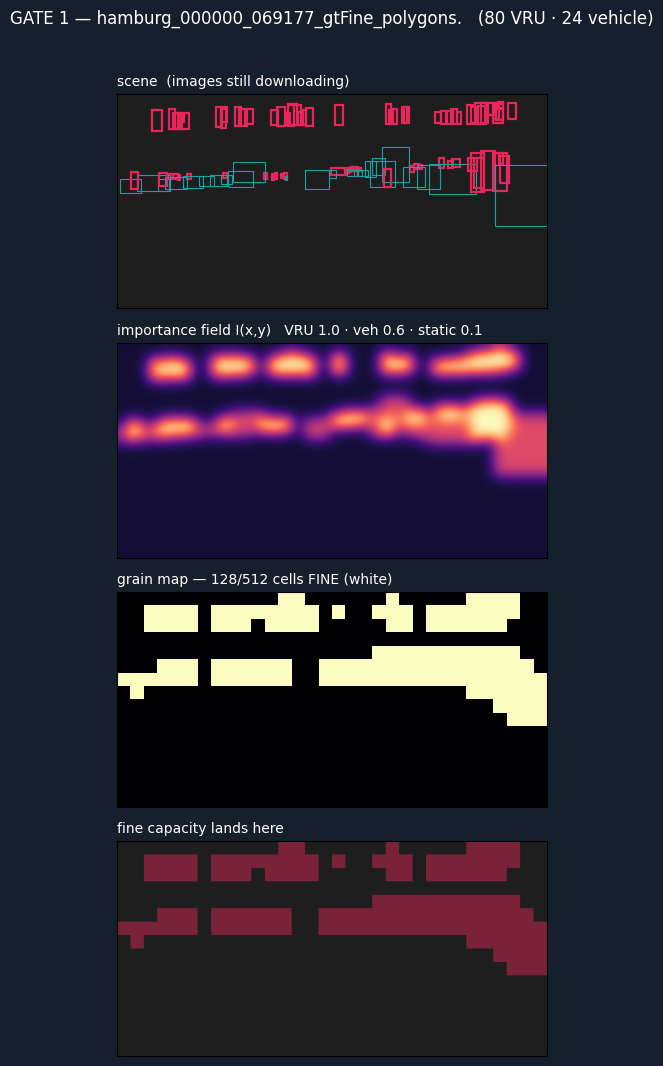

saved → /content/drive/MyDrive/pa_d2it/samples/gate1_grain_map.png


In [6]:
# ============================================================
# CELL 4 — Layout → Importance field → Grain map   ·   GATE 1
# ============================================================
import os, glob, json, subprocess, zipfile
import numpy as np
from collections import Counter
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

DATA_L = f"{LOCAL}/data"
GT_L, GT_D = f"{DATA_L}/gtFine_trainvaltest.zip", f"{ROOT}/data/gtFine_trainvaltest.zip"

# ---- 0. extract gtFine (Cell 3b only copied the zip) -----------------------
n_poly = lambda s: len(glob.glob(f"{DATA_L}/gtFine/{s}/*/*_gtFine_polygons.json"))
if n_poly("train") < 2975:
    src = GT_L if (os.path.exists(GT_L) and zipfile.is_zipfile(GT_L)) else GT_D
    assert os.path.exists(src) and zipfile.is_zipfile(src), f"no valid gtFine zip: {GT_L} / {GT_D}"
    print(f"Extracting gtFine from {src} …")
    subprocess.run(["unzip","-q","-o",src,"gtFine/train/*","gtFine/val/*","-d",DATA_L], check=True)
print(f"✓ gtFine polygons — train {n_poly('train')}  val {n_poly('val')}")

# ---- 1. geometry ----------------------------------------------------------
CELL   = cfg.vae_downsample * cfg.patch_coarse      # 16 image px per grain cell
GH, GW = cfg.img_h // CELL, cfg.img_w // CELL       # 16 × 32
N_CELLS = GH * GW
K_FINE  = int(round(cfg.r_fine * N_CELLS))          # fixed budget → fixed token count
TOKENS  = (N_CELLS - K_FINE) + K_FINE * cfg.patch_coarse**2
BLUR_PX = cfg.imp_blur_sigma * cfg.vae_downsample   # sigma in image px

# ---- 2. label → importance (handles Cityscapes '...group' labels) ---------
def importance_of(label):
    if label in cfg.class_importance: return cfg.class_importance[label], label
    if label.endswith("group") and label[:-5] in cfg.class_importance:
        return cfg.class_importance[label[:-5]], label[:-5]
    return None, None

def parse_layout(jp):
    """polygons JSON → list of axis-aligned boxes in cfg.img_h × cfg.img_w space."""
    d = json.load(open(jp))
    sx, sy = cfg.img_w / d["imgWidth"], cfg.img_h / d["imgHeight"]
    out = []
    for o in d["objects"]:
        w, base = importance_of(o["label"])
        if w is None: continue
        p = np.asarray(o["polygon"], float)
        if len(p) < 3: continue
        x0, y0 = p.min(0); x1, y1 = p.max(0)
        x0, x1 = max(0, x0*sx), min(cfg.img_w, x1*sx)
        y0, y1 = max(0, y0*sy), min(cfg.img_h, y1*sy)
        if x1-x0 < 1 or y1-y0 < 1: continue
        out.append(dict(label=base, w=w, box=(x0,y0,x1,y1),
                        tier="VRU" if base in VRU_CLASSES else "VEH"))
    return out

# ---- 3. importance field I(x,y) ------------------------------------------
def render_importance(objs, blur=True, min_vru_cells=1.0):
    I = np.full((cfg.img_h, cfg.img_w), cfg.imp_static, np.float32)
    for o in objs:
        x0, y0, x1, y1 = o["box"]
        if o["tier"] == "VRU":          # tiny distant VRUs must survive pooling
            cx, cy, h = (x0+x1)/2, (y0+y1)/2, CELL*min_vru_cells/2
            x0, x1 = min(x0, cx-h), max(x1, cx+h)
            y0, y1 = min(y0, cy-h), max(y1, cy+h)
        xs, ys = max(0,int(np.floor(x0))), max(0,int(np.floor(y0)))
        xe, ye = min(cfg.img_w,int(np.ceil(x1))), min(cfg.img_h,int(np.ceil(y1)))
        if xe > xs and ye > ys:
            np.maximum(I[ys:ye, xs:xe], o["w"], out=I[ys:ye, xs:xe])   # occlusion-safe
    return gaussian_filter(I, BLUR_PX) if blur else I

def to_cells(I):
    b = I.reshape(GH, CELL, GW, CELL)
    return b.max((1,3)), b.mean((1,3))

def grain_from_importance(I, k=K_FINE):
    """Top-k cells by importance → FINE. Fixed k ⇒ identical token count every image."""
    mx, mn = to_cells(I)
    score  = mx + 0.05*mn                       # max decides tier, mean breaks ties
    idx = np.argsort(-score.ravel(), kind="stable")[:k]
    g = np.zeros(N_CELLS, bool); g[idx] = True
    return g.reshape(GH, GW), score

# ---- 4. where does the fine budget actually land? -------------------------
train_json = sorted(glob.glob(f"{DATA_L}/gtFine/train/*/*_polygons.json"))
rng = np.random.default_rng(0)
probe = rng.choice(train_json, size=min(300, len(train_json)), replace=False)

acc = Counter(); nbox, vru_hit, vru_tot, imgs_with_vru = [], 0, 0, 0
for jp in probe:
    objs = parse_layout(jp); nbox.append(len(objs))
    I_raw = render_importance(objs, blur=False)
    grain, _ = grain_from_importance(render_importance(objs, blur=True))
    tier = to_cells(I_raw)[0]
    is_vru = tier >= cfg.imp_vru - 1e-3
    is_veh = (tier >= cfg.imp_vehicle - 1e-3) & ~is_vru
    acc["vru"]  += int((grain &  is_vru).sum())
    acc["veh"]  += int((grain &  is_veh).sum())
    acc["stat"] += int((grain & ~(is_vru|is_veh)).sum())
    if is_vru.any():
        imgs_with_vru += 1; vru_tot += int(is_vru.sum()); vru_hit += int((grain & is_vru).sum())

tot = sum(acc.values()); nbox = np.array(nbox)
bar = "─"*62
print("\n"+bar)
print(f"  grain grid   {GH} × {GW} = {N_CELLS} cells   ·   cell = {CELL}×{CELL} image px")
print(f"  fine budget  k = {K_FINE}  (r_fine={cfg.r_fine})")
print(f"  TOKENS/img   {TOKENS}   vs all-coarse {N_CELLS}  ·  all-fine {cfg.n_tokens_fine}")
print(f"               → fixed per image ⇒ dense batching + MATCHED COMPUTE vs D²iT-B")
print(bar)
print(f"  boxes/img    mean {nbox.mean():.1f}  median {np.median(nbox):.0f}  "
      f"p99 {np.percentile(nbox,99):.0f}  max {nbox.max()}")
print(bar)
print("  FINE-CELL ALLOCATION over 300 images")
print(f"    VRU (T1)      {acc['vru']/tot:6.1%}")
print(f"    vehicle (T2)  {acc['veh']/tot:6.1%}")
print(f"    static/halo   {acc['stat']/tot:6.1%}")
print(f"  VRU RECALL     {vru_hit/max(vru_tot,1):6.1%} of VRU cells got fine grain "
      f"({imgs_with_vru}/{len(probe)} imgs have VRUs)")
print(bar)

# ---- 5. GATE 1 visual -----------------------------------------------------
pick = max(probe, key=lambda j: sum(o["tier"]=="VRU" for o in parse_layout(j)))
objs = parse_layout(pick)
I    = render_importance(objs)
grain, score = grain_from_importance(I)
rgb_path = pick.replace("/gtFine/","/leftImg8bit/").replace("_gtFine_polygons.json","_leftImg8bit.png")
has_rgb  = os.path.exists(rgb_path)
rgb = np.asarray(Image.open(rgb_path).convert("RGB").resize((cfg.img_w,cfg.img_h), Image.BICUBIC))/255. \
      if has_rgb else np.full((cfg.img_h,cfg.img_w,3), .12)

NAVY, CRIM, TEAL = "#16202c", "#e8265a", "#17a2a8"
fig, ax = plt.subplots(4,1, figsize=(13,11), facecolor=NAVY)
fig.suptitle(f"GATE 1 — {os.path.basename(pick)[:38]}   "
             f"({sum(o['tier']=='VRU' for o in objs)} VRU · {sum(o['tier']=='VEH' for o in objs)} vehicle)",
             color="w", fontsize=12, y=.965)
ax[0].imshow(rgb); ax[0].set_title("scene" + ("" if has_rgb else "  (images still downloading)"),
                                   color="w", loc="left", fontsize=10)
for o in objs:
    x0,y0,x1,y1 = o["box"]
    ax[0].add_patch(Rectangle((x0,y0),x1-x0,y1-y0, fill=False,
                    ec=CRIM if o["tier"]=="VRU" else TEAL, lw=1.6 if o["tier"]=="VRU" else .8))
ax[1].imshow(I, cmap="magma", vmin=0, vmax=1)
ax[1].set_title(f"importance field I(x,y)   VRU {cfg.imp_vru} · veh {cfg.imp_vehicle} · static {cfg.imp_static}",
                color="w", loc="left", fontsize=10)
ax[2].imshow(np.kron(grain.astype(float), np.ones((CELL,CELL))), cmap="magma", vmin=0, vmax=1,
             interpolation="nearest")
ax[2].set_title(f"grain map — {grain.sum()}/{N_CELLS} cells FINE (white)", color="w", loc="left", fontsize=10)
ov = rgb.copy(); m = np.kron(grain, np.ones((CELL,CELL),bool))
ov[m] = .55*ov[m] + .45*np.array([.91,.15,.35])
ax[3].imshow(ov); ax[3].set_title("fine capacity lands here", color="w", loc="left", fontsize=10)
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(rect=[0,0,1,.95])
out = f"{ROOT}/samples/gate1_grain_map.png"; plt.savefig(out, dpi=110, facecolor=NAVY, bbox_inches="tight")
plt.show(); print(f"saved → {out}")


Extracting leftImg8bit (~11 GB, 2–4 min) …
✓ extracted in 0.4 min
✓ images — train 2975  val 500

──────────────────────────────────────────────────────────────
  VRU RECALL   old (blur-ranked)  93.3%
               new (tier-first)   94.7%
  recovered    121 VRU cells that blur had demoted below vehicles
──────────────────────────────────────────────────────────────
  VRU cells/img   mean  33.8  p50  23  p95 104  max 276   (budget k=128)
  budget-saturated images: 8/261 (3.1%) — 468 cells unavoidably lost
──────────────────────────────────────────────────────────────
  FINE-CELL ALLOCATION (new)
    VRU (T1)       21.7%
    vehicle (T2)   41.8%
    halo/static    36.5%
  → object cells fill ~64% of budget; r_fine≈0.16 would be the 'objects-only' setting
──────────────────────────────────────────────────────────────


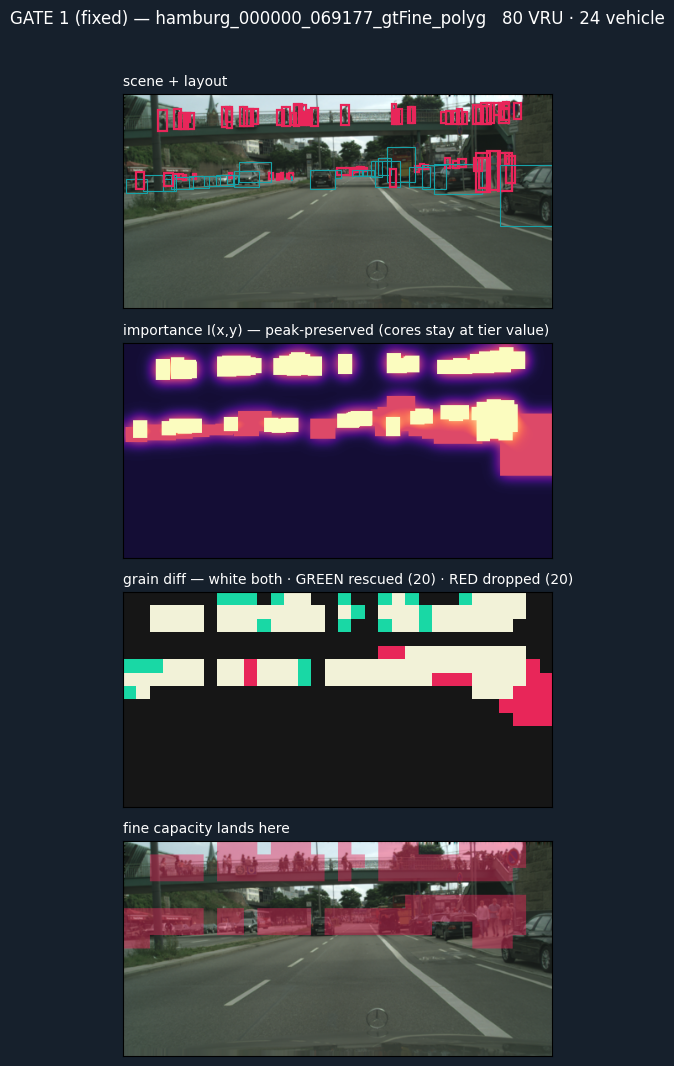

GATE 1 ✓ — next: Cell 5 = Dataset + DataLoader


In [7]:
# ============================================================
# CELL 4b — Extract images · fix blur dilution · re-validate GATE 1
# ============================================================
import os, glob, subprocess, zipfile, time
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# ---- 0. extract leftImg8bit (Cell 3c was skipped) -------------------------
DATA_L, LEFT_L = f"{LOCAL}/data", f"{LOCAL}/data/leftImg8bit_trainvaltest.zip"
n_img = lambda s: len(glob.glob(f"{DATA_L}/leftImg8bit/{s}/*/*_leftImg8bit.png"))
if n_img("train") < 2975:
    assert not os.path.exists(LEFT_L + ".aria2"), "download still running"
    assert zipfile.is_zipfile(LEFT_L), f"bad zip: {LEFT_L}"
    t = time.time(); print("Extracting leftImg8bit (~11 GB, 2–4 min) …", flush=True)
    subprocess.run(["unzip","-q","-o",LEFT_L,"leftImg8bit/train/*","leftImg8bit/val/*",
                    "-d",DATA_L], check=True)
    print(f"✓ extracted in {(time.time()-t)/60:.1f} min")
print(f"✓ images — train {n_img('train')}  val {n_img('val')}")

# ---- 1. peak-preserving field + tier-priority selection -------------------
def peak_preserved(I_raw):
    """Halo for context, but an object's core importance is never diluted."""
    return np.maximum(I_raw, gaussian_filter(I_raw, BLUR_PX))

def grain_v2(I_raw, k=K_FINE):
    """Lexicographic: exact tier decides, smooth score only breaks ties."""
    tier = to_cells(I_raw)[0]                       # max-pool of UNBLURRED field
    sm_max, sm_mean = to_cells(peak_preserved(I_raw))
    smooth = sm_max + 0.05 * sm_mean
    order = np.lexsort((-smooth.ravel(), -tier.ravel()))   # last key = primary
    g = np.zeros(N_CELLS, bool); g[order[:k]] = True
    return g.reshape(GH, GW), tier

# ---- 2. old vs new on the identical 300-image probe -----------------------
rng = np.random.default_rng(0)
train_json = sorted(glob.glob(f"{DATA_L}/gtFine/train/*/*_polygons.json"))
probe = rng.choice(train_json, size=300, replace=False)

o_hit = n_hit = tot = 0
sat_imgs = sat_loss = 0
vru_cell_counts, acc = [], {"vru":0, "veh":0, "halo":0}

for jp in probe:
    objs  = parse_layout(jp)
    I_raw = render_importance(objs, blur=False)
    g_old, _    = grain_from_importance(render_importance(objs, blur=True))
    g_new, tier = grain_v2(I_raw)

    is_vru = tier >= cfg.imp_vru - 1e-3
    is_veh = (tier >= cfg.imp_vehicle - 1e-3) & ~is_vru
    nv = int(is_vru.sum())
    if nv:
        vru_cell_counts.append(nv); tot += nv
        o_hit += int((g_old & is_vru).sum()); n_hit += int((g_new & is_vru).sum())
        if nv > K_FINE: sat_imgs += 1; sat_loss += nv - K_FINE
    acc["vru"]  += int((g_new &  is_vru).sum())
    acc["veh"]  += int((g_new &  is_veh).sum())
    acc["halo"] += int((g_new & ~(is_vru|is_veh)).sum())

vc = np.array(vru_cell_counts); s = sum(acc.values())
bar = "─"*62
print("\n"+bar)
print(f"  VRU RECALL   old (blur-ranked) {o_hit/tot:6.1%}")
print(f"               new (tier-first)  {n_hit/tot:6.1%}")
print(f"  recovered    {n_hit-o_hit} VRU cells that blur had demoted below vehicles")
print(bar)
print(f"  VRU cells/img   mean {vc.mean():5.1f}  p50 {np.percentile(vc,50):3.0f} "
      f" p95 {np.percentile(vc,95):3.0f}  max {vc.max():3.0f}   (budget k={K_FINE})")
print(f"  budget-saturated images: {sat_imgs}/{len(vc)} "
      f"({sat_imgs/len(vc):.1%}) — {sat_loss} cells unavoidably lost")
print(bar)
print("  FINE-CELL ALLOCATION (new)")
for lbl, key in [("VRU (T1)","vru"), ("vehicle (T2)","veh"), ("halo/static","halo")]:
    print(f"    {lbl:14s}{acc[key]/s:6.1%}")
print(f"  → object cells fill ~{(acc['vru']+acc['veh'])/s:.0%} of budget; "
      f"r_fine≈{(acc['vru']+acc['veh'])/s*cfg.r_fine:.2f} would be the 'objects-only' setting")
print(bar)

# ---- 3. GATE 1 figure, real imagery, old-vs-new diff ----------------------
pick  = max(probe, key=lambda j: sum(o["tier"]=="VRU" for o in parse_layout(j)))
objs  = parse_layout(pick)
I_raw = render_importance(objs, blur=False)
I_pp  = peak_preserved(I_raw)
g_old, _  = grain_from_importance(render_importance(objs, blur=True))
g_new, _  = grain_v2(I_raw)
rgb = np.asarray(Image.open(pick.replace("/gtFine/","/leftImg8bit/")
        .replace("_gtFine_polygons.json","_leftImg8bit.png")).convert("RGB")
        .resize((cfg.img_w,cfg.img_h), Image.BICUBIC))/255.

NAVY, CRIM, TEAL = "#16202c", "#e8265a", "#17a2a8"
fig, ax = plt.subplots(4,1, figsize=(13,11), facecolor=NAVY)
fig.suptitle(f"GATE 1 (fixed) — {os.path.basename(pick)[:34]}   "
             f"{sum(o['tier']=='VRU' for o in objs)} VRU · "
             f"{sum(o['tier']=='VEH' for o in objs)} vehicle",
             color="w", fontsize=12, y=.965)

ax[0].imshow(rgb); ax[0].set_title("scene + layout", color="w", loc="left", fontsize=10)
for o in objs:
    x0,y0,x1,y1 = o["box"]
    ax[0].add_patch(Rectangle((x0,y0),x1-x0,y1-y0, fill=False,
        ec=CRIM if o["tier"]=="VRU" else TEAL, lw=1.6 if o["tier"]=="VRU" else .8))

ax[1].imshow(I_pp, cmap="magma", vmin=0, vmax=1)
ax[1].set_title("importance I(x,y) — peak-preserved (cores stay at tier value)",
                color="w", loc="left", fontsize=10)

d = np.full((GH,GW,3), .09, np.float32)
d[g_old & g_new]  = [.95,.95,.85]
d[g_new & ~g_old] = [.10,.85,.65]
d[g_old & ~g_new] = [.91,.15,.35]
ax[2].imshow(np.kron(d, np.ones((CELL,CELL,1))), interpolation="nearest")
ax[2].set_title(f"grain diff — white both · GREEN rescued ({int((g_new&~g_old).sum())}) "
                f"· RED dropped ({int((g_old&~g_new).sum())})", color="w", loc="left", fontsize=10)

ov = rgb.copy(); m = np.kron(g_new, np.ones((CELL,CELL),bool))
ov[m] = .55*ov[m] + .45*np.array([.91,.15,.35])
ax[3].imshow(ov); ax[3].set_title("fine capacity lands here", color="w", loc="left", fontsize=10)
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(rect=[0,0,1,.95])
plt.savefig(f"{ROOT}/samples/gate1_fixed.png", dpi=110, facecolor=NAVY, bbox_inches="tight")
plt.show()
print("GATE 1 ✓ — next: Cell 5 = Dataset + DataLoader")

In [8]:
# ============================================================
# CELL 4c — State audit   ·   run AFTER 4b completes
# ============================================================
import os, glob, shutil

bar = "─"*62
print(bar); print("  GLOBALS IN MEMORY"); print(bar)
need = {
    "Cell 1 ": ["ROOT","LOCAL","BF16_OK"],
    "Cell 2 ": ["cfg","DTYPE","VRU_CLASSES","VEHICLE_CLASSES"],
    "Cell 4 ": ["CELL","GH","GW","N_CELLS","K_FINE","BLUR_PX",
                "parse_layout","render_importance","to_cells"],
    "Cell 4b": ["grain_v2","peak_preserved"],
}
gaps = []
for src, names in need.items():
    gone = [n for n in names if n not in globals()]; gaps += gone
    print(f"  {'✓' if not gone else '✗'} {src}  {len(names)-len(gone)}/{len(names)}"
          + (f"   MISSING {gone}" if gone else ""))

print(bar); print("  DISK"); print(bar)
D = f"{LOCAL}/data"
counts = {}
for s, exp in [("train",2975), ("val",500)]:
    img = len(glob.glob(f"{D}/leftImg8bit/{s}/*/*_leftImg8bit.png"))
    ann = len(glob.glob(f"{D}/gtFine/{s}/*/*_polygons.json"))
    counts[s] = (img, ann, exp)
    print(f"  {'✓' if img==ann==exp else '⚠'} {s:5s} images {img:5d} · polygons {ann:5d} (expect {exp})")

# the check only Cell 3c had: every image has its annotation
unpaired = [p for p in glob.glob(f"{D}/leftImg8bit/*/*/*_leftImg8bit.png")
            if not os.path.exists(p.replace("/leftImg8bit/","/gtFine/")
                                   .replace("_leftImg8bit.png","_gtFine_polygons.json"))]
print(f"  {'✓' if not unpaired else '⚠'} pairing: {len(unpaired)} unpaired over FULL set")
print(f"    free disk {shutil.disk_usage('/content').free/1024**3:.0f} GiB")

print(bar); print("  SURVIVES A SESSION RESET?"); print(bar)
for label, path in [("gtFine zip (Drive)", f"{ROOT}/data/gtFine_trainvaltest.zip"),
                    ("config json",        f"{ROOT}/logs/{cfg.run_name}_config.json"),
                    ("gate1 figures",      f"{ROOT}/samples")]:
    print(f"  {'✓' if os.path.exists(path) else '·'} {label}")
print("  ✗ leftImg8bit + all extracted files — local only, re-fetch in ~1.5 min")
print(bar)
ok = not gaps and not unpaired and all(i==a==e for i,a,e in counts.values())
print("STATE CLEAN — go to Cell 5." if ok else "⚠ resolve flags above.")

──────────────────────────────────────────────────────────────
  GLOBALS IN MEMORY
──────────────────────────────────────────────────────────────
  ✓ Cell 1   3/3
  ✓ Cell 2   4/4
  ✓ Cell 4   9/9
  ✓ Cell 4b  2/2
──────────────────────────────────────────────────────────────
  DISK
──────────────────────────────────────────────────────────────
  ✓ train images  2975 · polygons  2975 (expect 2975)
  ✓ val   images   500 · polygons   500 (expect 500)
  ✓ pairing: 0 unpaired over FULL set
    free disk 169 GiB
──────────────────────────────────────────────────────────────
  SURVIVES A SESSION RESET?
──────────────────────────────────────────────────────────────
  ✓ gtFine zip (Drive)
  ✓ config json
  ✓ gate1 figures
  ✗ leftImg8bit + all extracted files — local only, re-fetch in ~1.5 min
──────────────────────────────────────────────────────────────
STATE CLEAN — go to Cell 5.


Building layout cache …
    700/3475
    1400/3475
    2100/3475
    2800/3475
  ✓ layout cache 25s → 0.7 MB
  decoded 3475 PNGs in 8s (48 cpu)
  ✓ saved 1.37 GB → Drive in 1s (replaces the 11 GB download on session reset)
✓ dataset resident on GPU: 1.38 GB of 102 GB

──────────────────────────────────────────────────────────────
  images 3475  ·  boxes/img mean 19.3 p99.5 69 max 120  →  MAX_B=77 (13 truncated, VRU-safe)
──────────────────────────────────────────────────────────────
  image  (64, 3, 256, 512)    torch.float32  [ -1.00,  1.00]
  grain  (64, 16, 32)         torch.bool     [  0.00,  1.00]
  tier   (64, 16, 32)         torch.float32  [  0.10,  1.00]
  box    (64, 77, 4)          torch.float32  [  0.00,  1.00]
  cls    (64, 77)             torch.int64    [  0.00, 10.00]
  bmask  (64, 77)             torch.float32  [  0.00,  1.00]
  ✓ grain budget — all 128 fine cells (expect 128)
  ✓ hflip equivariance — grain
  ✗ hflip equivariance — boxes
  ✓ 44.5% of layout tokens are VR

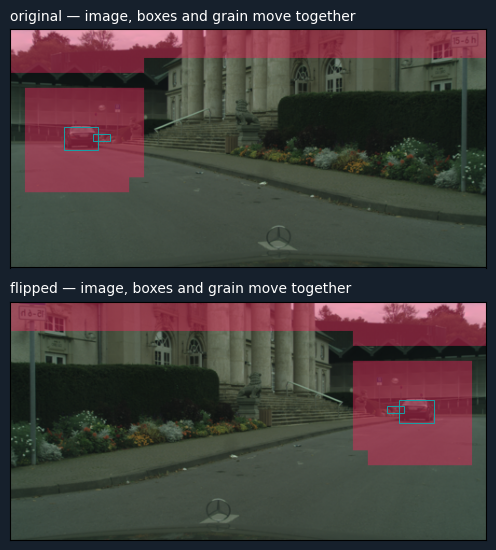

Cell 5 done → Cell 6 = frozen VAE, latents (also GPU-resident, ~220 MB)


In [9]:
# ============================================================
# CELL 5 — Layout cache · GPU-resident dataset · batcher
# ============================================================
import os, glob, time
import numpy as np, torch
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

dev       = "cuda"
DATA_L    = f"{LOCAL}/data"
LAY_CACHE = f"{ROOT}/data/layout_r{cfg.r_fine}_{cfg.img_h}x{cfg.img_w}.npz"
IMG_CACHE = f"{ROOT}/data/images_u8_{cfg.img_h}x{cfg.img_w}.npy"
CLASS_NAMES = ["<pad>"] + VRU_CLASSES + VEHICLE_CLASSES
CLASS_ID    = {c: i for i, c in enumerate(CLASS_NAMES)}
rel2png = lambda r: str(r).replace("gtFine/", "leftImg8bit/", 1) \
                          .replace("_gtFine_polygons.json", "_leftImg8bit.png")

# ---- 1. layout cache: parse polygons + render grain ONCE ------------------
def build_layout():
    t0 = time.time(); off, bx, im, cl, gr, ti, rel, sp = [0], [], [], [], [], [], [], []
    files = [(s, p) for s in ("train","val")
             for p in sorted(glob.glob(f"{DATA_L}/gtFine/{s}/*/*_polygons.json"))]
    for n, (split, jp) in enumerate(files):
        objs = parse_layout(jp)
        objs.sort(key=lambda o: -o["w"])              # VRU first ⇒ truncation is safe
        g, tier = grain_v2(render_importance(objs, blur=False))
        bx += [o["box"] for o in objs]; im += [o["w"] for o in objs]
        cl += [CLASS_ID[o["label"]] for o in objs]
        off.append(len(bx)); gr.append(g); ti.append(tier)
        rel.append(jp.replace(f"{DATA_L}/","")); sp.append(split)
        if (n+1) % 700 == 0: print(f"    {n+1}/{len(files)}", flush=True)
    d = dict(offsets=np.array(off,np.int64), boxes=np.array(bx,np.float32),
             imps=np.array(im,np.float32), clsid=np.array(cl,np.int16),
             grain=np.stack(gr), tier=np.stack(ti).astype(np.float32),
             rel=np.array(rel), split=np.array(sp))
    np.savez_compressed(LAY_CACHE, **d)
    print(f"  ✓ layout cache {time.time()-t0:.0f}s → {os.path.getsize(LAY_CACHE)/1e6:.1f} MB")
    return d

if os.path.exists(LAY_CACHE):
    C = dict(np.load(LAY_CACHE, allow_pickle=False)); print("✓ layout cache loaded")
else:
    print("Building layout cache …"); C = build_layout()
N = len(C["split"])

# ---- 2. decode every PNG once → uint8 array (Drive-cached) ----------------
if os.path.exists(IMG_CACHE):
    t0 = time.time(); IMG = np.load(IMG_CACHE)
    print(f"✓ image cache loaded from Drive in {time.time()-t0:.0f}s  {IMG.nbytes/1e9:.2f} GB")
else:
    t0 = time.time(); paths = [f"{DATA_L}/{rel2png(r)}" for r in C["rel"]]
    IMG = np.empty((N, cfg.img_h, cfg.img_w, 3), np.uint8)
    def _load(i):
        IMG[i] = np.asarray(Image.open(paths[i]).convert("RGB")
                            .resize((cfg.img_w, cfg.img_h), Image.BICUBIC))
    with ThreadPoolExecutor(min(32, os.cpu_count())) as ex: list(ex.map(_load, range(N)))
    print(f"  decoded {N} PNGs in {time.time()-t0:.0f}s ({os.cpu_count()} cpu)")
    t0 = time.time(); np.save(IMG_CACHE, IMG)
    print(f"  ✓ saved {IMG.nbytes/1e9:.2f} GB → Drive in {time.time()-t0:.0f}s "
          f"(replaces the 11 GB download on session reset)")

# ---- 3. pad layout to fixed width ----------------------------------------
nb    = np.diff(C["offsets"])
MAX_B = int(min(np.percentile(nb, 99.5) + 8, nb.max(), 96))
box_p = np.zeros((N, MAX_B, 4), np.float32); cls_p = np.zeros((N, MAX_B), np.int64)
msk_p = np.zeros((N, MAX_B), np.float32);    imp_p = np.zeros((N, MAX_B), np.float32)
S = np.array([cfg.img_w, cfg.img_h, cfg.img_w, cfg.img_h], np.float32)
for k in range(N):
    a, b = C["offsets"][k], C["offsets"][k+1]; n = min(b-a, MAX_B)
    if n:
        box_p[k,:n] = C["boxes"][a:a+n] / S       # normalised to [0,1]
        cls_p[k,:n] = C["clsid"][a:a+n]; msk_p[k,:n] = 1.; imp_p[k,:n] = C["imps"][a:a+n]

# ---- 4. everything resident on GPU ---------------------------------------
torch.cuda.empty_cache(); m0 = torch.cuda.memory_allocated()
G = dict(
    img   = torch.from_numpy(IMG).to(dev).permute(0,3,1,2).contiguous(),   # N,3,H,W u8
    grain = torch.from_numpy(C["grain"]).to(dev),
    tier  = torch.from_numpy(C["tier"]).to(dev),
    box   = torch.from_numpy(box_p).to(dev),   cls = torch.from_numpy(cls_p).to(dev),
    msk   = torch.from_numpy(msk_p).to(dev),   imp = torch.from_numpy(imp_p).to(dev))
torch.cuda.synchronize()
print(f"✓ dataset resident on GPU: {(torch.cuda.memory_allocated()-m0)/1e9:.2f} GB "
      f"of {torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")

IDX = {s: torch.from_numpy(np.where(C["split"]==s)[0]).to(dev) for s in ("train","val")}

class GPUBatcher:
    """Zero-copy batches straight out of GPU memory. hflip done on-device."""
    def __init__(self, split, bs=None, shuffle=True, augment=True, force_flip=None):
        self.ids, self.bs = IDX[split], bs or cfg.batch_size
        self.shuffle, self.augment, self.force_flip = shuffle, augment, force_flip
    def __len__(self):
        n = len(self.ids); return n//self.bs if self.shuffle else (n+self.bs-1)//self.bs
    def __iter__(self):
        o = self.ids[torch.randperm(len(self.ids), device=dev)] if self.shuffle else self.ids
        for i in range(len(self)): yield self.get(o[i*self.bs:(i+1)*self.bs])
    def get(self, ids):
        x = G["img"][ids].float().div_(127.5).sub_(1.)
        g, t, b = G["grain"][ids].clone(), G["tier"][ids].clone(), G["box"][ids].clone()
        if   self.force_flip is True:  f = torch.ones (len(ids), dtype=torch.bool, device=dev)
        elif self.force_flip is False: f = torch.zeros(len(ids), dtype=torch.bool, device=dev)
        elif self.augment and cfg.hflip: f = torch.rand(len(ids), device=dev) < .5
        else: f = torch.zeros(len(ids), dtype=torch.bool, device=dev)
        if f.any():
            x[f] = torch.flip(x[f], [-1]); g[f] = torch.flip(g[f], [-1]); t[f] = torch.flip(t[f], [-1])
            bf = b[f].clone(); bf[..., [0,2]] = 1. - bf[..., [2,0]]; b[f] = bf
            b = b * G["msk"][ids].unsqueeze(-1)      # re-zero padding
        return dict(image=x, grain=g, tier=t, box=b, cls=G["cls"][ids],
                    bmask=G["msk"][ids], bimp=G["imp"][ids], idx=ids, flip=f)

train_batches, val_batches = GPUBatcher("train"), GPUBatcher("val", shuffle=False, augment=False)

# ---- 5. sanity ------------------------------------------------------------
bar = "─"*62; print("\n"+bar)
print(f"  images {N}  ·  boxes/img mean {nb.mean():.1f} p99.5 {np.percentile(nb,99.5):.0f} "
      f"max {nb.max()}  →  MAX_B={MAX_B} ({(nb>MAX_B).sum()} truncated, VRU-safe)")
print(bar)
B = next(iter(train_batches))
for k_ in ("image","grain","tier","box","cls","bmask"):
    v = B[k_]; print(f"  {k_:6s} {str(tuple(v.shape)):20s} {str(v.dtype):14s}"
                     f" [{v.float().min():6.2f}, {v.float().max():5.2f}]")
gs = B["grain"].sum((1,2))
print(f"  {'✓' if (gs==K_FINE).all() else '✗'} grain budget — all {gs.min().item()} "
      f"fine cells (expect {K_FINE})")
a, b_ = train_batches.get(IDX["train"][:32]), None
a2 = GPUBatcher("train", force_flip=False).get(IDX["train"][:32])
b2 = GPUBatcher("train", force_flip=True ).get(IDX["train"][:32])
eq_g = torch.equal(torch.flip(a2["grain"], [-1]), b2["grain"])
eq_b = torch.allclose(torch.where(a2["bmask"][...,None]>0, 1-a2["box"][...,[2,1,0,3]], a2["box"]*0),
                      torch.where(b2["bmask"][...,None]>0, b2["box"][...,[0,1,2,3]]*1, b2["box"]*0), atol=1e-5)
print(f"  {'✓' if eq_g else '✗'} hflip equivariance — grain")
print(f"  {'✓' if eq_b else '✗'} hflip equivariance — boxes")
vru = (B["cls"][B["bmask"]>0] <= len(VRU_CLASSES)).float().mean()
print(f"  ✓ {vru:.1%} of layout tokens are VRU · {int(B['bmask'].sum(1).max())} max boxes in batch")
torch.cuda.synchronize(); t0 = time.time(); n_ = 0
for i, _b in enumerate(train_batches):
    n_ += cfg.batch_size
    if i == 29: break
torch.cuda.synchronize()
ips = n_/(time.time()-t0)
print(f"  ⏱ {ips:,.0f} img/s  ·  {len(train_batches)} steps/epoch  ·  {2975/ips*1000:.0f} ms/epoch of data")
print(bar)

# ---- 6. visual: flip consistency -----------------------------------------
fig, ax = plt.subplots(2,1, figsize=(13,5.6), facecolor="#16202c")
for r, bt in enumerate([a2, b2]):
    im_ = ((bt["image"][7].permute(1,2,0).cpu().numpy())+1)/2
    m = np.kron(bt["grain"][7].cpu().numpy(), np.ones((CELL,CELL), bool))
    im_ = im_.copy(); im_[m] = .55*im_[m] + .45*np.array([.91,.15,.35])
    ax[r].imshow(im_)
    for bx_, c_, mk_ in zip(bt["box"][7].cpu().numpy(), bt["cls"][7].cpu().numpy(),
                            bt["bmask"][7].cpu().numpy()):
        if mk_ == 0: continue
        x0,y0,x1,y1 = bx_*S
        ax[r].add_patch(Rectangle((x0,y0),x1-x0,y1-y0, fill=False,
            ec="#e8265a" if c_ <= len(VRU_CLASSES) else "#17a2a8",
            lw=1.6 if c_ <= len(VRU_CLASSES) else .7))
    ax[r].set_xticks([]); ax[r].set_yticks([])
    ax[r].set_title(f"{'flipped' if r else 'original'} — image, boxes and grain move together",
                    color="w", loc="left", fontsize=10)
plt.tight_layout(); plt.savefig(f"{ROOT}/samples/cell5_aug.png", dpi=110,
                                facecolor="#16202c", bbox_inches="tight"); plt.show()
print("Cell 5 done → Cell 6 = frozen VAE, latents (also GPU-resident, ~220 MB)")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  ✓ hflip equivariance — boxes (corrected test)


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  335MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

✓ VAE stabilityai/sd-vae-ft-mse · 84M frozen (8s) · latent 4×32×64
    flip=0 done
    flip=1 done
✓ encoded 6950 images in 57s → 228 MB on Drive
  latent stats after ×0.18215:  mean +0.110  std 0.808   ✓ ≈unit

──────────────────────────────────────────────────────────────
  VAE RECONSTRUCTION FLOOR — object-region PSNR (dB)
     height (px)              VRU          vehicle
            < 16    23.0 (n= 545)    21.0 (n= 956)
           16–32    23.1 (n= 748)    21.9 (n= 687)
           32–64    23.6 (n= 481)    23.9 (n= 301)
            ≥ 64    24.8 (n= 178)    27.5 (n= 144)
      background    24.8 (n= 200)
──────────────────────────────────────────────────────────────
  small VRU (<32px) vs large VRU (≥64px): 23.1 vs 24.8 dB → +1.7 dB gap
  small VRU vs background:                23.1 vs 24.8 dB
  ⚠ this is the CEILING on object-region FID — no DiT on top can beat it
──────────────────────────────────────────────────────────────


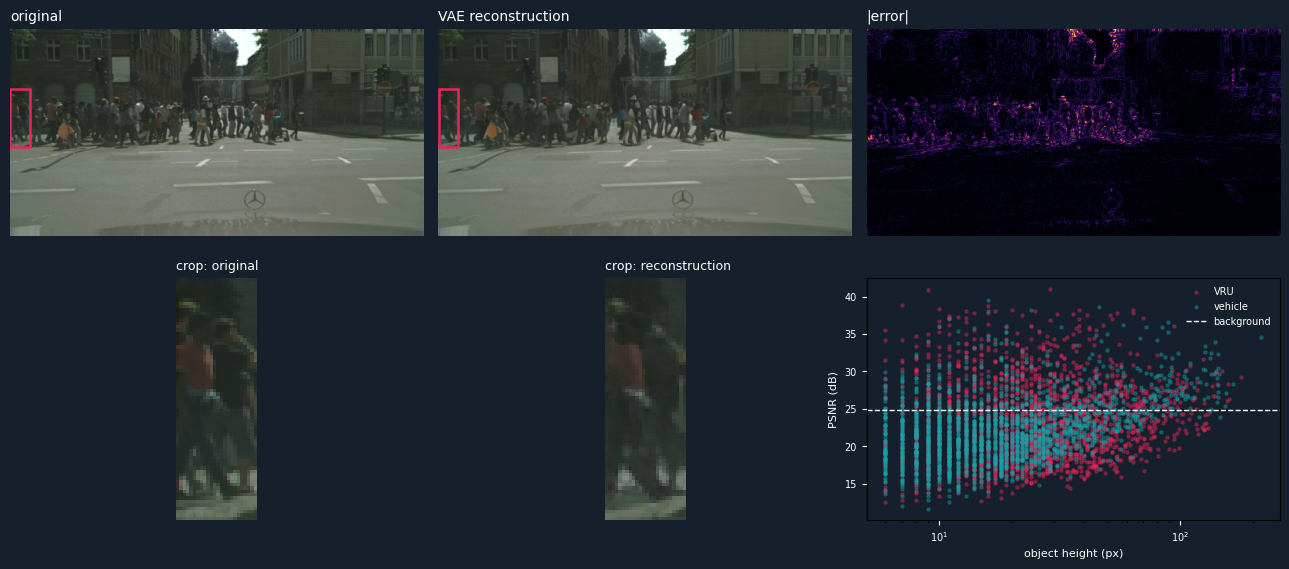

Cell 6 done → Cell 7 = dynamic patchify + importance router (the novel module)


In [10]:
# ============================================================
# CELL 6 — Frozen VAE · latents (both flips) · reconstruction FLOOR
# ============================================================
import os, time
import numpy as np, torch
import matplotlib.pyplot as plt

os.environ["HF_HOME"] = f"{ROOT}/hf"; os.makedirs(os.environ["HF_HOME"], exist_ok=True)
from diffusers import AutoencoderKL

# ---- 0. corrected hflip box assertion ------------------------------------
A  = GPUBatcher("train", force_flip=False).get(IDX["train"][:64])
Bf = GPUBatcher("train", force_flip=True ).get(IDX["train"][:64])
m  = A["bmask"] > 0
exp = A["box"].clone()
exp[...,0] = 1. - A["box"][...,2]      # x0' = 1-x1
exp[...,2] = 1. - A["box"][...,0]      # x1' = 1-x0   (y untouched)
print(f"  {'✓' if torch.allclose(exp[m], Bf['box'][m], atol=1e-6) else '✗'} "
      f"hflip equivariance — boxes (corrected test)")

# ---- 1. frozen VAE --------------------------------------------------------
t0 = time.time()
vae = AutoencoderKL.from_pretrained(cfg.vae_id).to(dev).eval().requires_grad_(False)
LH, LW = cfg.latent_h, cfg.latent_w
print(f"✓ VAE {cfg.vae_id} · {sum(p.numel() for p in vae.parameters())/1e6:.0f}M frozen "
      f"({time.time()-t0:.0f}s) · latent {cfg.latent_ch}×{LH}×{LW}")

@torch.no_grad()
def encode(x):  d = vae.encode(x).latent_dist; return d.mean, d.std
@torch.no_grad()
def decode(z):  return vae.decode(z / cfg.vae_scale).sample

# ---- 2. precompute latents, both flips -----------------------------------
LAT = f"{ROOT}/data/latents_{cfg.img_h}x{cfg.img_w}.npz"
if os.path.exists(LAT):
    _z = np.load(LAT); LM = torch.from_numpy(_z["mean"]).to(dev); LS = torch.from_numpy(_z["std"]).to(dev)
    print(f"✓ latent cache loaded  {LM.nbytes/1e6:.0f} MB")
else:
    t0 = time.time(); CH = 48
    LM = torch.empty(N,2,cfg.latent_ch,LH,LW, dtype=torch.float16, device=dev)
    LS = torch.empty_like(LM)
    for fl in (0,1):
        for s in range(0, N, CH):
            ids = torch.arange(s, min(s+CH,N), device=dev)
            x = G["img"][ids].float().div_(127.5).sub_(1.)
            if fl: x = torch.flip(x, [-1])
            mu, sd = encode(x)
            LM[ids,fl] = mu.half(); LS[ids,fl] = sd.half()
        print(f"    flip={fl} done", flush=True)
    np.savez(LAT, mean=LM.cpu().numpy(), std=LS.cpu().numpy())
    print(f"✓ encoded {2*N} images in {time.time()-t0:.0f}s → {os.path.getsize(LAT)/1e6:.0f} MB on Drive")

def sample_latent(ids, flip):
    """z ~ q(z|x), scaled. Matches SD training exactly."""
    mu, sd = LM[ids, flip.long()].float(), LS[ids, flip.long()].float()
    return (mu + sd*torch.randn_like(sd)) * cfg.vae_scale

zs = sample_latent(IDX["train"][:512], torch.zeros(512, dtype=torch.bool, device=dev))
print(f"  latent stats after ×{cfg.vae_scale}:  mean {zs.mean():+.3f}  std {zs.std():.3f}"
      f"   {'✓ ≈unit' if .8 < zs.std() < 1.25 else '⚠ off-unit — noise schedule assumes ~1'}")

# ---- 3. THE FLOOR: what does the frozen VAE do to small VRUs? ------------
vi = IDX["val"][:200]
psnr_of = lambda a,b: (10*torch.log10(1./((a-b).pow(2).mean().clamp_min(1e-10)))).item()
rows, recon_store = [], {}
for s in range(0, len(vi), 16):
    ids = vi[s:s+16]
    o = G["img"][ids].float().div_(127.5).sub_(1.)
    r = decode(LM[ids,0].float()*cfg.vae_scale).clamp(-1,1)
    o01, r01 = (o+1)/2, (r+1)/2
    for j, k in enumerate(ids.tolist()):
        recon_store[k] = (o01[j].cpu(), r01[j].cpu())
        a,b = C["offsets"][k], C["offsets"][k+1]
        for bx, w in zip(C["boxes"][a:b], C["imps"][a:b]):
            x0,y0,x1,y1 = [int(v) for v in bx]
            h_, w_ = y1-y0, x1-x0
            if h_ < 6 or w_ < 4: continue
            rows.append((h_, w >= cfg.imp_vru-1e-3,
                         psnr_of(o01[j,:,y0:y1,x0:x1], r01[j,:,y0:y1,x0:x1])))
        # background control: sky/road strip, same image
        rows.append((999, None, psnr_of(o01[j,:,:40,:], r01[j,:,:40,:])))

R = np.array([(h, -1 if v is None else int(v), p) for h,v,p in rows])
bar = "─"*62; print("\n"+bar)
print("  VAE RECONSTRUCTION FLOOR — object-region PSNR (dB)")
print(f"  {'height (px)':>14}   {'VRU':>14}   {'vehicle':>14}")
for lo,hi,lbl in [(6,16,"< 16"),(16,32,"16–32"),(32,64,"32–64"),(64,999,"≥ 64")]:
    sel = (R[:,0]>=lo)&(R[:,0]<hi)
    v = R[sel&(R[:,1]==1),2]; c = R[sel&(R[:,1]==0),2]
    f = lambda a: f"{a.mean():5.1f} (n={len(a):4d})" if len(a) else "        —     "
    print(f"  {lbl:>14}   {f(v)}   {f(c)}")
bg = R[R[:,0]==999,2]
print(f"  {'background':>14}   {bg.mean():5.1f} (n={len(bg):4d})")
print(bar)
tiny = R[(R[:,0]<32)&(R[:,1]==1),2]; big = R[(R[:,0]>=64)&(R[:,1]==1),2]
print(f"  small VRU (<32px) vs large VRU (≥64px): {tiny.mean():.1f} vs {big.mean():.1f} dB "
      f"→ {big.mean()-tiny.mean():+.1f} dB gap")
print(f"  small VRU vs background:                {tiny.mean():.1f} vs {bg.mean():.1f} dB")
print("  ⚠ this is the CEILING on object-region FID — no DiT on top can beat it" if tiny.mean()<24
      else "  ✓ headroom is adequate at all VRU scales")
print(bar)

# ---- 4. visual: the floor, zoomed on a pedestrian ------------------------
k = max(recon_store, key=lambda k: sum(
    1 for bx,w in zip(C["boxes"][C["offsets"][k]:C["offsets"][k+1]],
                      C["imps"][C["offsets"][k]:C["offsets"][k+1]])
    if w>=cfg.imp_vru-1e-3 and 20 < bx[3]-bx[1] < 70))
o01, r01 = recon_store[k]
a,b = C["offsets"][k], C["offsets"][k+1]
cand = [bx for bx,w in zip(C["boxes"][a:b], C["imps"][a:b])
        if w>=cfg.imp_vru-1e-3 and 20 < bx[3]-bx[1] < 70]
bx = max(cand, key=lambda z: (z[3]-z[1])) if cand else C["boxes"][a]
x0,y0,x1,y1 = [int(v) for v in bx]; pad=6
cy0,cy1 = max(0,y0-pad), min(cfg.img_h,y1+pad); cx0,cx1 = max(0,x0-pad), min(cfg.img_w,x1+pad)

fig = plt.figure(figsize=(13,6.2), facecolor="#16202c")
gs_ = fig.add_gridspec(2,3, height_ratios=[1.35,1])
for c_,(im_,ti_) in enumerate([(o01,"original"),(r01,"VAE reconstruction")]):
    ax = fig.add_subplot(gs_[0,c_]); ax.imshow(im_.permute(1,2,0).numpy())
    ax.add_patch(plt.Rectangle((cx0,cy0),cx1-cx0,cy1-cy0,fill=False,ec="#e8265a",lw=1.8))
    ax.set_title(ti_, color="w", loc="left", fontsize=10); ax.axis("off")
ax = fig.add_subplot(gs_[0,2])
err = (o01-r01).abs().mean(0).numpy(); ax.imshow(err, cmap="inferno", vmax=err.max()*.7)
ax.set_title("|error|", color="w", loc="left", fontsize=10); ax.axis("off")
for c_,(im_,ti_) in enumerate([(o01,"crop: original"),(r01,"crop: reconstruction")]):
    ax = fig.add_subplot(gs_[1,c_])
    ax.imshow(im_[:,cy0:cy1,cx0:cx1].permute(1,2,0).numpy(), interpolation="nearest")
    ax.set_title(ti_, color="w", loc="left", fontsize=9); ax.axis("off")
ax = fig.add_subplot(gs_[1,2]); ax.set_facecolor("#16202c")
for lab, sel, col in [("VRU", R[:,1]==1, "#e8265a"), ("vehicle", R[:,1]==0, "#17a2a8")]:
    d = R[sel & (R[:,0]<400)]
    if len(d): ax.scatter(d[:,0], d[:,2], s=5, alpha=.35, c=col, label=lab)
ax.axhline(bg.mean(), color="w", ls="--", lw=1, label="background")
ax.set_xlabel("object height (px)", color="w", fontsize=8)
ax.set_ylabel("PSNR (dB)", color="w", fontsize=8); ax.set_xscale("log")
ax.tick_params(colors="w", labelsize=7); ax.legend(fontsize=7, facecolor="#16202c",
    labelcolor="w", edgecolor="none")
plt.tight_layout(); plt.savefig(f"{ROOT}/samples/cell6_vae_floor.png", dpi=110,
    facecolor="#16202c", bbox_inches="tight"); plt.show()
print("Cell 6 done → Cell 7 = dynamic patchify + importance router (the novel module)")

──────────────────────────────────────────────────────────────
  ✓ index permutation — all 2048 latent positions covered exactly once, no overlap
  ✓ split→merge round-trip is bit-exact
  ✓ tokens (64, 896, 768) = 384 coarse + 128×4 fine = 896
  ✓ constant across batch → no padding, no ragged attention
  ✓ routing invariant to latent noise resample (deterministic at every timestep t)
  ✓ k=0    →   512 tokens   [DiT-B all-coarse]
  ✓ k=128  →   896 tokens   [D²iT-B / PA-D²iT]
  ✓ k=512  →  2048 tokens   [all-fine]
──────────────────────────────────────────────────────────────
  FORWARD GFLOPs / image (DiT blocks only)
    DiT-B (uniform p=2)        512 tok      96.6   (0.53× ours)
    DiT-B + layout             512 tok      96.6   (0.53× ours)
    D²iT-B  entropy grain      896 tok     181.8   (1.00× ours)
    PA-D²iT ours               896 tok     181.8   (1.00× ours)
    all-fine  p=1             2048 tok     502.5   (2.76× ours)
  → D²iT-B and PA-D²iT differ ONLY in which cells are 

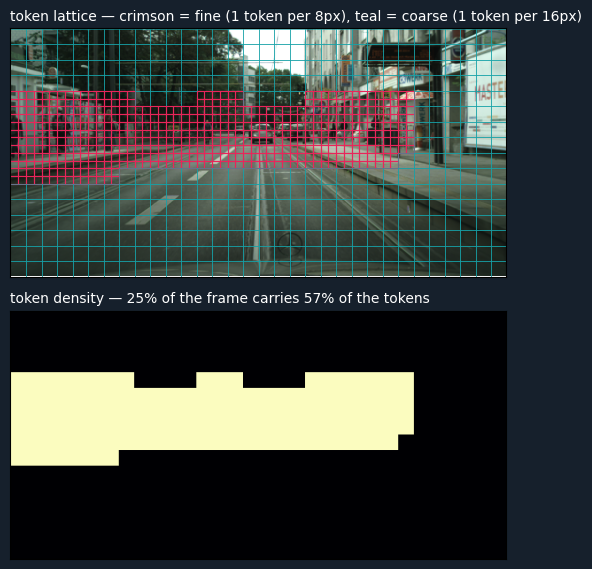

params: patchify 0.03M
Cell 7 done → Cell 8 = entropy grain map (D²iT-B's signal) + disagreement analysis


In [11]:
# ============================================================
# CELL 7 — Dynamic patchify · the importance router
# ============================================================
import math, torch, torch.nn as nn, numpy as np
from einops import rearrange
import matplotlib.pyplot as plt

P      = cfg.patch_coarse                 # 2×2 latent block per coarse cell
LH, LW = cfg.latent_h, cfg.latent_w
NC     = GH * GW                          # 512 cells
NL     = LH * LW                          # 2048 latent positions
Cch    = cfg.latent_ch

# cell → its P² latent positions (fixed lookup, built once)
_i, _j   = np.divmod(np.arange(NC), GW)
_p, _q   = np.divmod(np.arange(P*P), P)
CELL2LAT = torch.from_numpy(((_i[:,None]*P + _p[None,:]) * LW +
                             (_j[:,None]*P + _q[None,:]))).long().to(dev)   # (512,4)

# ---- fixed 2D sin-cos position embedding, evaluated at CONTINUOUS coords --
def sincos2d(dim, coords):
    q = dim // 4
    om = 1. / (10000 ** (torch.arange(q, dtype=torch.float64) / q))
    return torch.cat([f(coords[:, k:k+1].double() * om[None])
                      for k in range(2) for f in (torch.sin, torch.cos)], 1).float()

_r, _c = np.divmod(np.arange(NL), LW)
COORD_C = torch.stack([torch.from_numpy(_i).float()*P + P/2,          # cell centres
                       torch.from_numpy(_j).float()*P + P/2], 1)
COORD_F = torch.stack([torch.from_numpy(_r).float() + .5,             # pixel centres
                       torch.from_numpy(_c).float() + .5], 1)

# ---- routing: grain map → gather indices ---------------------------------
def route(grain, k=K_FINE):
    """Coarse tokens first, then fine. Deterministic, timestep-independent."""
    g = grain.flatten(1).int()
    order = torch.argsort(g, dim=1, stable=True)          # False (coarse) sorts first
    cc, fc = order[:, :NC-k], order[:, NC-k:]
    return cc, fc, CELL2LAT[cc], CELL2LAT[fc].flatten(1)  # (B,nc) (B,k) (B,nc,4) (B,4k)

def split(z, b):
    cc, fc, cpos, fpos = b; B = z.shape[0]
    flat = rearrange(z, 'b c h w -> b (h w) c')
    cv = flat.gather(1, cpos.flatten(1).unsqueeze(-1).expand(-1,-1,Cch))
    return cv.reshape(B, cc.shape[1], P*P*Cch), \
           flat.gather(1, fpos.unsqueeze(-1).expand(-1,-1,Cch))

def merge(cv, fv, b):
    cc, fc, cpos, fpos = b; B = cv.shape[0]
    buf = torch.zeros(B, NL, Cch, device=cv.device, dtype=cv.dtype)
    if cv.shape[1]: buf.scatter_(1, cpos.flatten(1).unsqueeze(-1).expand(-1,-1,Cch).contiguous(),
                                 cv.reshape(B, -1, Cch))
    if fv.shape[1]: buf.scatter_(1, fpos.unsqueeze(-1).expand(-1,-1,Cch).contiguous(), fv)
    return rearrange(buf, 'b (h w) c -> b c h w', h=LH)

class DynamicPatchify(nn.Module):
    """Mixed-grain tokenisation. k_fine fixed ⇒ constant token count ⇒ dense batching."""
    def __init__(self, hidden, k_fine=K_FINE):
        super().__init__()
        self.k, self.h = k_fine, hidden
        self.n_tok = (NC - k_fine) + k_fine * P*P
        self.emb_c, self.emb_f = nn.Linear(P*P*Cch, hidden), nn.Linear(Cch, hidden)
        self.out_c, self.out_f = nn.Linear(hidden, P*P*Cch), nn.Linear(hidden, Cch)
        self.grain_emb = nn.Parameter(torch.randn(2, hidden) * .02)
        self.register_buffer("pos_c", sincos2d(hidden, COORD_C))
        self.register_buffer("pos_f", sincos2d(hidden, COORD_F))
        for m in (self.out_c, self.out_f):                # DiT convention: zero-init heads
            nn.init.zeros_(m.weight); nn.init.zeros_(m.bias)

    def tokens(self, z, grain):
        b = route(grain, self.k); cv, fv = split(z, b)
        t = [self.emb_c(cv) + self.pos_c[b[0]] + self.grain_emb[0],
             self.emb_f(fv) + self.pos_f[b[3]] + self.grain_emb[1]]
        return torch.cat(t, 1), b

    def unpatchify(self, h, b):
        n = NC - self.k
        return merge(self.out_c(h[:, :n]), self.out_f(h[:, n:]), b)

# ============================ VERIFY =====================================
D_ = cfg.dit_hidden
pat = DynamicPatchify(D_).to(dev)
Bt  = next(iter(train_batches))
z   = sample_latent(Bt["idx"], Bt["flip"])
bnd = route(Bt["grain"])
bar = "─"*62; print(bar)

# 1. every latent position covered exactly once
allp = torch.cat([bnd[2].flatten(1), bnd[3]], 1).sort(1).values
ref  = torch.arange(NL, device=dev).expand(allp.shape[0], -1)
print(f"  {'✓' if torch.equal(allp, ref) else '✗'} index permutation — all {NL} latent "
      f"positions covered exactly once, no overlap")

# 2. exact value round-trip
print(f"  {'✓' if torch.equal(merge(*split(z, bnd), bnd), z) else '✗'} "
      f"split→merge round-trip is bit-exact")

# 3. token stream
tok, _ = pat.tokens(z, Bt["grain"])
print(f"  {'✓' if tok.shape[1]==pat.n_tok==896 else '✗'} tokens {tuple(tok.shape)} "
      f"= {NC-K_FINE} coarse + {K_FINE}×{P*P} fine = {pat.n_tok}")
print(f"  ✓ constant across batch → no padding, no ragged attention")

# 4. router is independent of z and of t  (the D²iT-vs-MoE argument)
z2 = sample_latent(Bt["idx"], Bt["flip"])
b2 = route(Bt["grain"])
same = all(torch.equal(a, c) for a, c in zip(bnd, b2))
print(f"  {'✓' if same else '✗'} routing invariant to latent noise resample "
      f"(deterministic at every timestep t)")

# 5. baselines share the code path
for name, k in [("DiT-B all-coarse", 0), ("D²iT-B / PA-D²iT", K_FINE), ("all-fine", NC)]:
    m = DynamicPatchify(D_, k).to(dev)
    tk, bb = m.tokens(z, Bt["grain"])
    ok = torch.equal(m.unpatchify(torch.zeros_like(tk), bb), torch.zeros_like(z))
    print(f"  {'✓' if ok else '✗'} k={k:<4d} → {tk.shape[1]:5d} tokens   [{name}]")
print(bar)

# ---- FLOP accounting: matched compute is STRUCTURAL, not argued ----------
def gflops(n, d=D_, L=cfg.dit_depth):
    return 2*L*(12*n*d*d + 2*n*n*d) / 1e9
print("  FORWARD GFLOPs / image (DiT blocks only)")
base = gflops(pat.n_tok)
for name, n in [("DiT-B (uniform p=2)", NC), ("DiT-B + layout", NC),
                ("D²iT-B  entropy grain", pat.n_tok), ("PA-D²iT ours", pat.n_tok),
                ("all-fine  p=1", NL)]:
    print(f"    {name:24s} {n:5d} tok   {gflops(n):7.1f}   ({gflops(n)/base:.2f}× ours)")
print(f"  → D²iT-B and PA-D²iT differ ONLY in which cells are fine. Identical FLOPs, "
      f"identical params.\n    H1 is testable with zero compute confound.")
print(bar)

# ---- visual: where the tokens actually are -------------------------------
n_ = 7
g_  = Bt["grain"][n_].cpu().numpy()
img = ((Bt["image"][n_].permute(1,2,0).cpu().numpy())+1)/2
fig, ax = plt.subplots(2,1, figsize=(13,5.8), facecolor="#16202c")
ax[0].imshow(img)
for i in range(GH):
    for j in range(GW):
        y, x = i*CELL, j*CELL
        if g_[i,j]:
            for a_ in range(P):
                for b_ in range(P):
                    ax[0].add_patch(plt.Rectangle((x+b_*CELL/P, y+a_*CELL/P), CELL/P, CELL/P,
                                    fill=False, ec="#e8265a", lw=.8))
        else:
            ax[0].add_patch(plt.Rectangle((x,y), CELL, CELL, fill=False, ec="#17a2a8", lw=.45))
ax[0].set_title(f"token lattice — crimson = fine (1 token per {cfg.vae_downsample}px), "
                f"teal = coarse (1 token per {CELL}px)", color="w", loc="left", fontsize=10)
dens = np.kron(g_.astype(float)*P*P + (1-g_.astype(float)), np.ones((CELL,CELL)))
im_ = ax[1].imshow(dens, cmap="magma"); ax[1].set_title(
    f"token density — {(dens>1).mean():.0%} of the frame carries {K_FINE*P*P/pat.n_tok:.0%} "
    f"of the tokens", color="w", loc="left", fontsize=10)
for a_ in ax: a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout(); plt.savefig(f"{ROOT}/samples/cell7_tokens.png", dpi=110,
    facecolor="#16202c", bbox_inches="tight"); plt.show()
print(f"params: patchify {sum(p.numel() for p in pat.parameters())/1e6:.2f}M")
print("Cell 7 done → Cell 8 = entropy grain map (D²iT-B's signal) + disagreement analysis")

✓ entropy+random grain built in 1s → 6.4 MB
  ✓ all three signals allocate exactly k=128 fine cells

────────────────────────────────────────────────────────────────────
  signal                VRU recall  veh recall  %budget→VRU  %budget→bg
────────────────────────────────────────────────────────────────────
  importance (ours)         96.0%      87.5%       19.8%      35.7%
  entropy (D²iT)            51.8%      43.7%       10.7%      67.1%
  random (control)          25.2%      25.1%        5.2%      82.0%
────────────────────────────────────────────────────────────────────
  grain-map overlap   importance ∩ entropy  42.1%
                      importance ∩ random   25.1%
                      entropy    ∩ random   25.1%
  cell-level corr(entropy, importance) = +0.287
────────────────────────────────────────────────────────────────────
  ► entropy reaches 52% of VRU cells vs random's 25% — better than chance
  ► ours reaches 96%.  Headroom over D²iT = +44% of VRU cells
  ► the two m

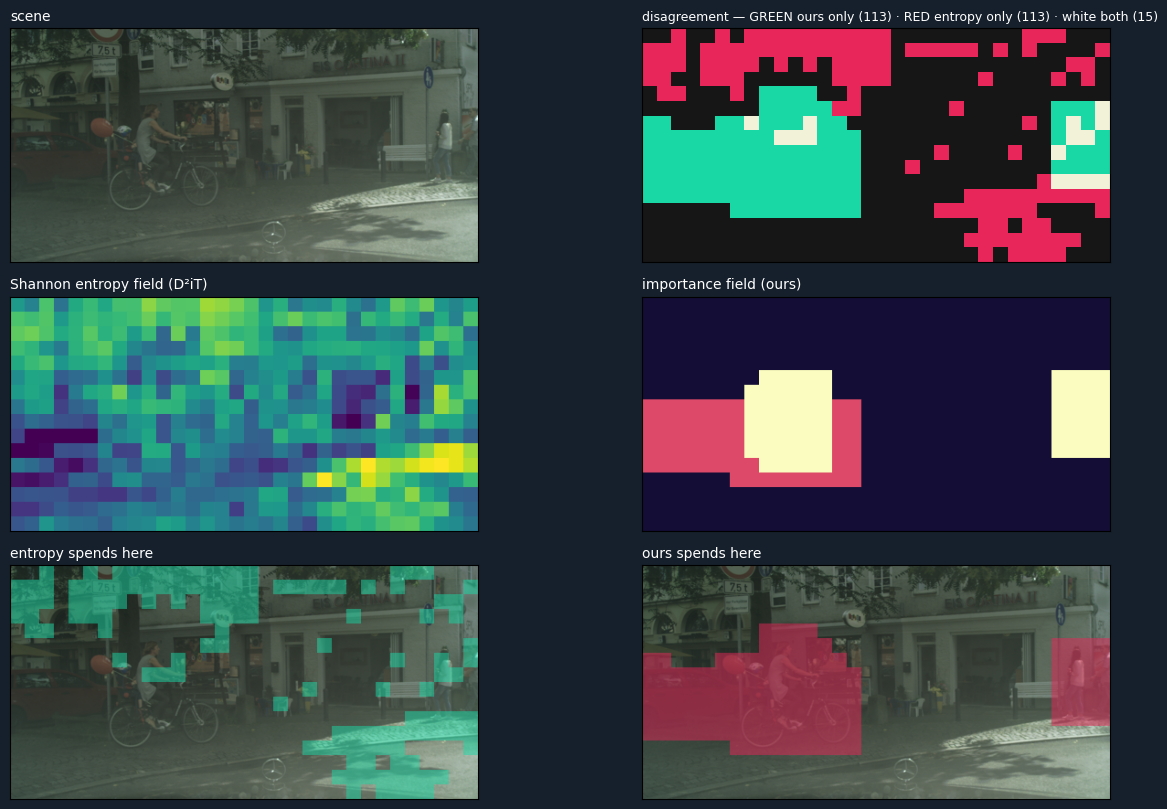

  ✓ GPUBatcher(signal=…) → ['importance', 'entropy', 'random', 'none']
Cell 8 done → Cell 9 = the DiT backbone + layout cross-attention


In [12]:
# ============================================================
# CELL 8 — Entropy grain (D²iT's signal) · random control · disagreement
# ============================================================
import os, time
import numpy as np, torch
import matplotlib.pyplot as plt

NBINS = 32
ENT_CACHE = f"{ROOT}/data/grain_ent_rnd_{cfg.img_h}x{cfg.img_w}_b{NBINS}_k{K_FINE}.npz"

# ---- 1. local Shannon entropy per cell (D²iT's allocation signal) --------
@torch.no_grad()
def entropy_cells(img_u8, nbins=NBINS):
    B = img_u8.shape[0]
    w = torch.tensor([.299,.587,.114], device=dev).view(1,3,1,1)
    g = (img_u8.float()*w).sum(1)
    q = (g*(nbins/256.)).long().clamp_(0, nbins-1)
    q = q.reshape(B,GH,CELL,GW,CELL).permute(0,1,3,2,4).reshape(B*NC, CELL*CELL)
    h = torch.zeros(B*NC, nbins, device=dev)
    h.scatter_add_(1, q, torch.ones_like(q, dtype=torch.float))
    p = h/(CELL*CELL)
    return (-(p*torch.log2(p.clamp_min(1e-12))).sum(1)).reshape(B,GH,GW)

def topk_grain(score, k=K_FINE):
    idx = score.flatten(1).topk(k, dim=1).indices
    g = torch.zeros(score.shape[0], NC, dtype=torch.bool, device=dev)
    return g.scatter_(1, idx, True).reshape(-1, GH, GW)

# ---- 2. build / load entropy + random grain ------------------------------
if os.path.exists(ENT_CACHE):
    _c = np.load(ENT_CACHE)
    ENT_FIELD = torch.from_numpy(_c["field"]).to(dev)
    G["grain_ent"] = torch.from_numpy(_c["ent"]).to(dev)
    G["grain_rnd"] = torch.from_numpy(_c["rnd"]).to(dev)
    print("✓ entropy/random grain cache loaded")
else:
    t0 = time.time()
    ENT_FIELD = torch.empty(N,GH,GW, device=dev)
    for s in range(0, N, 256):
        ids = torch.arange(s, min(s+256,N), device=dev)
        ENT_FIELD[ids] = entropy_cells(G["img"][ids])
    G["grain_ent"] = topk_grain(ENT_FIELD)
    gen = torch.Generator(device=dev).manual_seed(1234)      # fixed ⇒ reproducible control
    G["grain_rnd"] = topk_grain(torch.rand(N, GH, GW, device=dev, generator=gen))
    np.savez_compressed(ENT_CACHE, field=ENT_FIELD.cpu().numpy(),
                        ent=G["grain_ent"].cpu().numpy(), rnd=G["grain_rnd"].cpu().numpy())
    print(f"✓ entropy+random grain built in {time.time()-t0:.0f}s → "
          f"{os.path.getsize(ENT_CACHE)/1e6:.1f} MB")

for k_ in ("grain_ent","grain_rnd"):
    assert (G[k_].flatten(1).sum(1) == K_FINE).all(), f"{k_} budget drift"
print(f"  ✓ all three signals allocate exactly k={K_FINE} fine cells")

# ---- 3. disagreement over the full dataset -------------------------------
tier = G["tier"]
is_vru = tier >= cfg.imp_vru - 1e-3
is_veh = (tier >= cfg.imp_vehicle - 1e-3) & ~is_vru
is_bg  = ~(is_vru | is_veh)
sig = {"importance (ours)": G["grain"], "entropy (D²iT)": G["grain_ent"],
       "random (control)":  G["grain_rnd"]}

bar = "─"*68; print("\n"+bar)
print(f"  {'signal':20s} {'VRU recall':>11} {'veh recall':>11} "
      f"{'%budget→VRU':>12} {'%budget→bg':>11}")
print(bar)
stats = {}
for name, gm in sig.items():
    vr = (gm & is_vru).sum().item() / is_vru.sum().item()
    hr = (gm & is_veh).sum().item() / is_veh.sum().item()
    bv = (gm & is_vru).sum().item() / gm.sum().item()
    bb = (gm & is_bg ).sum().item() / gm.sum().item()
    stats[name] = (vr, hr, bv, bb)
    print(f"  {name:20s} {vr:10.1%} {hr:10.1%} {bv:11.1%} {bb:10.1%}")
print(bar)

ov = lambda a,b: ((a&b).flatten(1).sum(1).float()/K_FINE).mean().item()
print(f"  grain-map overlap   importance ∩ entropy  {ov(G['grain'],G['grain_ent']):.1%}")
print(f"                      importance ∩ random   {ov(G['grain'],G['grain_rnd']):.1%}")
print(f"                      entropy    ∩ random   {ov(G['grain_ent'],G['grain_rnd']):.1%}")
ef = ENT_FIELD.flatten(); tf = tier.flatten()
cc = torch.corrcoef(torch.stack([ef, tf]))[0,1].item()
print(f"  cell-level corr(entropy, importance) = {cc:+.3f}")
print(bar)
e_vru, i_vru = stats["entropy (D²iT)"][0], stats["importance (ours)"][0]
r_vru = stats["random (control)"][0]
print(f"  ► entropy reaches {e_vru:.0%} of VRU cells vs random's {r_vru:.0%} "
      f"— {'barely better than chance' if e_vru < r_vru*1.6 else 'better than chance'}")
print(f"  ► ours reaches {i_vru:.0%}.  Headroom over D²iT = {i_vru-e_vru:+.0%} of VRU cells")
print(f"  ► the two maps disagree on {1-ov(G['grain'],G['grain_ent']):.0%} of the fine budget")
print(bar)

# ---- 4. per-class VRU recall breakdown -----------------------------------
print("  VRU recall by object height")
hb = [(6,16,"<16px"),(16,32,"16–32"),(32,64,"32–64"),(64,999,"≥64")]
hits = {n: {l:[0,0] for *_,l in hb} for n in sig}
for k in range(0, N, 1):
    a,b = C["offsets"][k], C["offsets"][k+1]
    for bx, w in zip(C["boxes"][a:b], C["imps"][a:b]):
        if w < cfg.imp_vru-1e-3: continue
        h_ = bx[3]-bx[1]
        lab = next((l for lo,hi,l in hb if lo<=h_<hi), None)
        if lab is None: continue
        ci0,ci1 = int(bx[1]//CELL), int(np.ceil(bx[3]/CELL))
        cj0,cj1 = int(bx[0]//CELL), int(np.ceil(bx[2]/CELL))
        for n,gm in sig.items():
            reg = gm[k, ci0:ci1, cj0:cj1]
            hits[n][lab][0] += int(reg.any()); hits[n][lab][1] += 1
print(f"  {'signal':20s}" + "".join(f"{l:>10}" for *_,l in hb))
for n in sig:
    print(f"  {n:20s}" + "".join(f"{hits[n][l][0]/max(hits[n][l][1],1):9.0%} " for *_,l in hb))
print(bar)

# ---- 5. THE motivating figure --------------------------------------------
dis = (G["grain"] ^ G["grain_ent"]).flatten(1).sum(1)
vrucnt = is_vru.flatten(1).sum(1)
pick = int(((dis.float()/K_FINE) * (vrucnt.float().clamp(5,60)/60)).argmax())
img = (G["img"][pick].permute(1,2,0).float()/255).cpu().numpy()
gi, ge = G["grain"][pick].cpu().numpy(), G["grain_ent"][pick].cpu().numpy()
ef_ = ENT_FIELD[pick].cpu().numpy(); tf_ = tier[pick].cpu().numpy()
up = lambda a: np.kron(a, np.ones((CELL,CELL)))

fig, ax = plt.subplots(3,2, figsize=(14,8.2), facecolor="#16202c")
ax[0,0].imshow(img); ax[0,0].set_title("scene", color="w", loc="left", fontsize=10)
d = np.zeros((GH,GW,3)); d[...] = .09
d[gi&ge]  = [.95,.95,.85]; d[gi&~ge] = [.10,.85,.65]; d[ge&~gi] = [.91,.15,.35]
ax[0,1].imshow(np.kron(d, np.ones((CELL,CELL,1))), interpolation="nearest")
ax[0,1].set_title(f"disagreement — GREEN ours only ({int((gi&~ge).sum())}) · "
                  f"RED entropy only ({int((ge&~gi).sum())}) · white both ({int((gi&ge).sum())})",
                  color="w", loc="left", fontsize=9)
ax[1,0].imshow(up(ef_), cmap="viridis"); ax[1,0].set_title(
    "Shannon entropy field (D²iT)", color="w", loc="left", fontsize=10)
ax[1,1].imshow(up(tf_), cmap="magma", vmin=0, vmax=1); ax[1,1].set_title(
    "importance field (ours)", color="w", loc="left", fontsize=10)
for c_,(gm,ti_) in enumerate([(ge,"entropy spends here"),(gi,"ours spends here")]):
    o = img.copy(); m = up(gm).astype(bool)
    o[m] = .5*o[m] + .5*np.array([.91,.15,.35] if c_ else [.10,.85,.65])
    ax[2,c_].imshow(o); ax[2,c_].set_title(ti_, color="w", loc="left", fontsize=10)
for a_ in ax.ravel(): a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout(); plt.savefig(f"{ROOT}/samples/cell8_entropy_vs_importance.png",
    dpi=115, facecolor="#16202c", bbox_inches="tight"); plt.show()

# ---- 6. wire signals into the batcher ------------------------------------
_GB = GPUBatcher
class GPUBatcher(_GB):
    KEY = {"importance":"grain", "entropy":"grain_ent", "random":"grain_rnd", "none":"grain"}
    def __init__(self, split, signal="importance", **kw):
        super().__init__(split, **kw); self.signal = signal
    def get(self, ids):
        d = super().get(ids)
        if self.signal != "importance":
            g = G[self.KEY[self.signal]][ids].clone()
            if d["flip"].any(): g[d["flip"]] = torch.flip(g[d["flip"]], [-1])
            d["grain"] = g
        return d
train_batches = GPUBatcher("train")
val_batches   = GPUBatcher("val", shuffle=False, augment=False)
print(f"  ✓ GPUBatcher(signal=…) → {list(GPUBatcher.KEY)}")
print("Cell 8 done → Cell 9 = the DiT backbone + layout cross-attention")

──────────────────────────────────────────────────────────────────────
  MEAN COVERAGE — fraction of each VRU's cells given FINE grain
  signal                    <16px      16–32      32–64        ≥64      ALL
  importance (ours)          99%        99%        99%        93%      99%
  entropy (D²iT)             72%        64%        55%        43%      64%
  random (control)           25%        26%        25%        25%      25%
──────────────────────────────────────────────────────────────────────
  signal                fully covered   partial   missed
  importance (ours)              97%        3%       0%
  entropy (D²iT)                 34%       57%       9%
  random (control)                4%       59%      36%
──────────────────────────────────────────────────────────────────────
  ► 23112 VRU instances.  Ours fully covers 97%, entropy 34%.
  ► entropy leaves 57% of VRUs SPLIT across both grains — part fine, part coarse.
─────────────────────────────────────────────────────

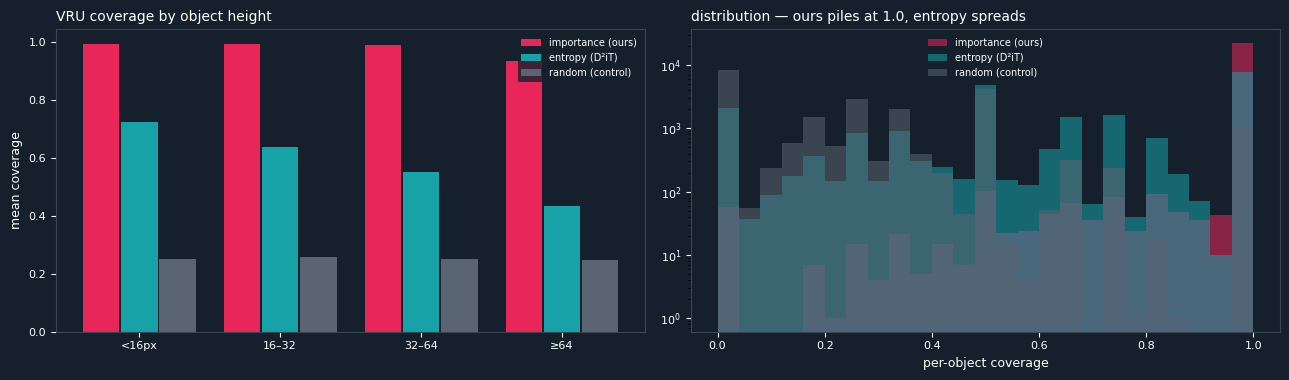

In [13]:
# ============================================================
# CELL 8b — Coverage fraction (replaces the 'any cell' metric)
# ============================================================
import numpy as np, matplotlib.pyplot as plt

hb  = [(6,16,"<16px"),(16,32,"16–32"),(32,64,"32–64"),(64,999,"≥64")]
sig = {"importance (ours)": G["grain"], "entropy (D²iT)": G["grain_ent"],
       "random (control)":  G["grain_rnd"]}
gm  = {n: g.cpu().numpy() for n, g in sig.items()}

recs = []
for k in range(N):
    a, b = C["offsets"][k], C["offsets"][k+1]
    for bx, w in zip(C["boxes"][a:b], C["imps"][a:b]):
        if w < cfg.imp_vru - 1e-3: continue
        lab = next((l for lo,hi,l in hb if lo <= bx[3]-bx[1] < hi), None)
        if lab is None: continue
        ci0, ci1 = int(bx[1]//CELL), min(int(np.ceil(bx[3]/CELL)), GH)
        cj0, cj1 = int(bx[0]//CELL), min(int(np.ceil(bx[2]/CELL)), GW)
        if ci1 > ci0 and cj1 > cj0: recs.append((k, lab, ci0, ci1, cj0, cj1))

cov = {n: {l: [] for *_, l in hb} for n in sig}
for k, lab, ci0, ci1, cj0, cj1 in recs:
    for n in sig: cov[n][lab].append(gm[n][k, ci0:ci1, cj0:cj1].mean())
cov = {n: {l: np.array(v) for l, v in d.items()} for n, d in cov.items()}
allv = {n: np.concatenate([cov[n][l] for *_, l in hb]) for n in sig}

bar = "─"*70; print(bar)
print("  MEAN COVERAGE — fraction of each VRU's cells given FINE grain")
print(f"  {'signal':20s}" + "".join(f"{l:>11}" for *_, l in hb) + f"{'ALL':>9}")
for n in sig:
    print(f"  {n:20s}" + "".join(f"{cov[n][l].mean():10.0%} " for *_, l in hb)
          + f"{allv[n].mean():8.0%}")
print(bar)
print(f"  {'signal':20s}{'fully covered':>15}{'partial':>10}{'missed':>9}")
for n in sig:
    v = allv[n]
    print(f"  {n:20s}{(v>=.999).mean():14.0%}{((v>0)&(v<.999)).mean():10.0%}{(v==0).mean():9.0%}")
print(bar)
print(f"  ► {len(recs)} VRU instances.  Ours fully covers {(allv['importance (ours)']>=.999).mean():.0%}, "
      f"entropy {(allv['entropy (D²iT)']>=.999).mean():.0%}.")
print(f"  ► entropy leaves {((allv['entropy (D²iT)']>0)&(allv['entropy (D²iT)']<.999)).mean():.0%} "
      f"of VRUs SPLIT across both grains — part fine, part coarse.")
print(bar)

col = {"importance (ours)":"#e8265a", "entropy (D²iT)":"#17a2a8", "random (control)":"#5a6472"}
fig, ax = plt.subplots(1, 2, figsize=(13,3.9), facecolor="#16202c")
x = np.arange(len(hb))
for i, n in enumerate(sig):
    ax[0].bar(x+(i-1)*.27, [cov[n][l].mean() for *_, l in hb], .26, color=col[n], label=n)
ax[0].set_xticks(x); ax[0].set_xticklabels([l for *_, l in hb])
ax[0].set_ylabel("mean coverage", color="w", fontsize=9)
ax[0].set_title("VRU coverage by object height", color="w", loc="left", fontsize=10)
for n in sig:
    ax[1].hist(allv[n], bins=np.linspace(0,1,26), alpha=.55, color=col[n], label=n)
ax[1].set_yscale("log"); ax[1].set_xlabel("per-object coverage", color="w", fontsize=9)
ax[1].set_title("distribution — ours piles at 1.0, entropy spreads", color="w", loc="left", fontsize=10)
for a_ in ax:
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=8)
    a_.legend(fontsize=7, facecolor="#16202c", labelcolor="w", edgecolor="none")
    for s_ in a_.spines.values(): s_.set_color("#3a4654")
plt.tight_layout(); plt.savefig(f"{ROOT}/samples/cell8b_coverage.png", dpi=115,
    facecolor="#16202c", bbox_inches="tight"); plt.show()

In [14]:
# ============================================================
# CELL 9 — DiT-B · adaLN-Zero · layout cross-attention
# ============================================================
import math, time
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np

N_CLS = len(CLASS_NAMES)

def t_embed(t, dim, max_period=10000):
    half = dim // 2
    f = torch.exp(-math.log(max_period) *
                  torch.arange(half, device=t.device, dtype=torch.float32) / half)
    a = t.float()[:, None] * f[None]
    return torch.cat([torch.cos(a), torch.sin(a)], -1)

def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

# ---- layout → conditioning tokens (GLIGEN-style Fourier boxes) -----------
class LayoutEncoder(nn.Module):
    def __init__(self, d, n_cls, n_freq=8):
        super().__init__()
        self.register_buffer("freq", 2. ** torch.arange(n_freq) * math.pi)
        self.cls = nn.Embedding(n_cls, d)
        self.mlp = nn.Sequential(nn.Linear(d + 8*n_freq + 1, d), nn.SiLU(), nn.Linear(d, d))
        self.null = nn.Parameter(torch.randn(d) * .02)      # CFG unconditional slot
    def forward(self, box, cls, imp, mask, drop=None):
        B, M, _ = box.shape
        p  = box.unsqueeze(-1) * self.freq
        ff = torch.cat([p.sin(), p.cos()], -1).flatten(2)
        h  = self.mlp(torch.cat([self.cls(cls), ff, imp.unsqueeze(-1)], -1)) * mask.unsqueeze(-1)
        one = torch.ones(B, 1, device=box.device)
        h = torch.cat([self.null.expand(B,1,-1), h], 1)      # null always valid ⇒ no NaN
        m = torch.cat([one, mask if drop is None else mask*(~drop).float().unsqueeze(1)], 1)
        return h, m

class SelfAttn(nn.Module):
    def __init__(self, d, h):
        super().__init__(); self.h = h
        self.qkv, self.proj = nn.Linear(d, 3*d), nn.Linear(d, d)
    def forward(self, x):
        B, N_, D = x.shape
        q,k,v = self.qkv(x).reshape(B,N_,3,self.h,D//self.h).permute(2,0,3,1,4)
        return self.proj(F.scaled_dot_product_attention(q,k,v).transpose(1,2).reshape(B,N_,D))

class CrossAttn(nn.Module):
    def __init__(self, d, h):
        super().__init__(); self.h = h
        self.q, self.kv, self.proj = nn.Linear(d,d), nn.Linear(d,2*d), nn.Linear(d,d)
    def forward(self, x, ctx, mask):
        B, N_, D = x.shape; M = ctx.shape[1]
        q = self.q(x).reshape(B,N_,self.h,D//self.h).transpose(1,2)
        k,v = self.kv(ctx).reshape(B,M,2,self.h,D//self.h).permute(2,0,3,1,4)
        o = F.scaled_dot_product_attention(q,k,v, attn_mask=mask[:,None,None,:].bool())
        return self.proj(o.transpose(1,2).reshape(B,N_,D))

class Block(nn.Module):
    def __init__(self, d, h, mlp_ratio, use_layout):
        super().__init__()
        nrm = lambda: nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)
        self.n1, self.attn = nrm(), SelfAttn(d, h)
        self.use_layout = use_layout
        if use_layout:
            self.nca, self.cross = nrm(), CrossAttn(d, h)
            self.ca_gate = nn.Parameter(torch.zeros(d))     # zero-init ⇒ identity at step 0
        self.n2 = nrm()
        self.mlp = nn.Sequential(nn.Linear(d, int(d*mlp_ratio)), nn.GELU(approximate="tanh"),
                                 nn.Linear(int(d*mlp_ratio), d))
        self.ada = nn.Sequential(nn.SiLU(), nn.Linear(d, 6*d))
        nn.init.zeros_(self.ada[1].weight); nn.init.zeros_(self.ada[1].bias)
    def forward(self, x, c, ctx=None, cmask=None):
        s1, c1, g1, s2, c2, g2 = self.ada(c).chunk(6, -1)
        x = x + g1.unsqueeze(1) * self.attn(modulate(self.n1(x), s1, c1))
        if self.use_layout:
            x = x + self.ca_gate * self.cross(self.nca(x), ctx, cmask)
        return x + g2.unsqueeze(1) * self.mlp(modulate(self.n2(x), s2, c2))

class PAD2iT(nn.Module):
    """One class, every arm of the ablation ladder. k_fine=0 ⇒ uniform coarse (DiT-B)."""
    def __init__(self, k_fine=K_FINE, use_layout=True):
        super().__init__()
        d = cfg.dit_hidden
        self.k_fine, self.use_layout = k_fine, use_layout
        self.patch = DynamicPatchify(d, k_fine)
        self.t_mlp = nn.Sequential(nn.Linear(d, d), nn.SiLU(), nn.Linear(d, d))
        self.layout = LayoutEncoder(d, N_CLS) if use_layout else None
        self.blocks = nn.ModuleList([Block(d, cfg.dit_heads, cfg.dit_mlp_ratio, use_layout)
                                     for _ in range(cfg.dit_depth)])
        self.nf  = nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)
        self.adaf = nn.Sequential(nn.SiLU(), nn.Linear(d, 2*d))
        nn.init.zeros_(self.adaf[1].weight); nn.init.zeros_(self.adaf[1].bias)
        for m in self.modules():
            if isinstance(m, nn.Linear) and m.weight.requires_grad and m.weight.abs().sum() > 0:
                pass
        self.apply(self._init)
        for blk in self.blocks:                      # re-zero after generic init
            nn.init.zeros_(blk.ada[1].weight); nn.init.zeros_(blk.ada[1].bias)
        nn.init.zeros_(self.adaf[1].weight); nn.init.zeros_(self.adaf[1].bias)
        nn.init.zeros_(self.patch.out_c.weight); nn.init.zeros_(self.patch.out_c.bias)
        nn.init.zeros_(self.patch.out_f.weight); nn.init.zeros_(self.patch.out_f.bias)
    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, z, t, grain, box=None, cls=None, imp=None, bmask=None, drop=None):
        h, bnd = self.patch.tokens(z, grain)
        c = self.t_mlp(t_embed(t, cfg.dit_hidden))
        ctx = cmask = None
        if self.use_layout:
            ctx, cmask = self.layout(box, cls, imp, bmask, drop)
        for blk in self.blocks:
            h = blk(h, c, ctx, cmask)
        s, sc = self.adaf(c).chunk(2, -1)
        return self.patch.unpatchify(modulate(self.nf(h), s, sc), bnd)

# ============================ VERIFY =====================================
torch.manual_seed(cfg.seed)
model = PAD2iT().to(dev)
B_ = next(iter(train_batches))
z  = sample_latent(B_["idx"], B_["flip"])
t  = torch.randint(0, cfg.num_timesteps, (z.shape[0],), device=dev)
bar = "─"*68; print(bar)

with torch.autocast("cuda", DTYPE):
    out = model(z, t, B_["grain"], B_["box"], B_["cls"], B_["bimp"], B_["bmask"])
print(f"  {'✓' if out.shape==z.shape else '✗'} output {tuple(out.shape)} matches latent {tuple(z.shape)}")
print(f"  {'✓' if out.abs().max()==0 else '✗'} zero-init — model predicts exactly 0 at step 0 "
      f"(max |out| = {out.abs().max():.2e})")

drop = torch.rand(z.shape[0], device=dev) < .5
with torch.autocast("cuda", DTYPE):
    o2 = model(z, t, B_["grain"], B_["box"], B_["cls"], B_["bimp"], B_["bmask"], drop=drop)
print(f"  {'✓' if torch.isfinite(o2).all() else '✗'} CFG layout-dropout path finite "
      f"({drop.sum().item()}/{len(drop)} dropped)")

# capacity ratio made explicit: perturb one token, count affected latent positions
with torch.no_grad():
    bnd = route(B_["grain"]); n_c = NC - K_FINE
    hh = torch.zeros(1, model.patch.n_tok, cfg.dit_hidden, device=dev)
    bnd1 = tuple(x[:1] for x in bnd)
    model.patch.out_c.weight.normal_(0,.02); model.patch.out_f.weight.normal_(0,.02)
    base = model.patch.unpatchify(hh, bnd1)
    hc = hh.clone(); hc[0, 0] = 1.;        nc_ = (model.patch.unpatchify(hc,bnd1)-base).abs().sum(1).gt(0).sum()
    hf = hh.clone(); hf[0, n_c] = 1.;      nf_ = (model.patch.unpatchify(hf,bnd1)-base).abs().sum(1).gt(0).sum()
    nn.init.zeros_(model.patch.out_c.weight); nn.init.zeros_(model.patch.out_f.weight)
print(f"  {'✓' if (nc_,nf_)==(P*P,1) else '✗'} capacity ratio — 1 coarse token drives "
      f"{nc_} latent positions, 1 fine token drives {nf_}  ({P*P}× density)")
print(bar)

# ---- the ablation ladder --------------------------------------------------
def gflops(n, d=cfg.dit_hidden, L=cfg.dit_depth, m=0):
    mac = L*(12*n*d*d + 2*n*n*d + (2*m*d*d + 2*n*m*d if m else 0))
    return 2*mac/1e9
M_ = MAX_B + 1
print(f"  {'arm':26s}{'layout':>8}{'k':>6}{'tokens':>8}{'params':>10}{'GFLOPs':>9}")
variants = [("DiT-B  (uniform)", False, 0), ("DiT-B + layout", True, 0),
            ("D²iT-B  entropy", True, K_FINE), ("PA-D²iT  ours", True, K_FINE),
            ("random control", True, K_FINE)]
seen = {}
for name, lay, k in variants:
    key = (lay, k)
    if key not in seen:
        torch.manual_seed(cfg.seed)
        mm = PAD2iT(k, lay); seen[key] = (sum(p.numel() for p in mm.parameters()), mm.patch.n_tok)
        del mm
    pn, nt = seen[key]
    print(f"  {name:26s}{'yes' if lay else 'no':>8}{k:>6}{nt:>8}{pn/1e6:>9.1f}M"
          f"{gflops(nt, m=M_ if lay else 0):>9.1f}")
print(f"  → rows 3–5 identical in params AND FLOPs. Only the grain SIGNAL differs.")
print(bar)

# ---- throughput / batch sizing -------------------------------------------
opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
def bench(bs, iters=12):
    ids = IDX["train"][:bs]
    b = train_batches.get(ids); zz = sample_latent(b["idx"], b["flip"])
    tt = torch.randint(0, cfg.num_timesteps, (bs,), device=dev)
    torch.cuda.reset_peak_memory_stats()
    for i in range(iters):
        if i == 2: torch.cuda.synchronize(); t0 = time.time()
        with torch.autocast("cuda", DTYPE):
            loss = (model(zz, tt, b["grain"], b["box"], b["cls"], b["bimp"], b["bmask"])
                    - torch.randn_like(zz)).pow(2).mean()
        loss.backward(); opt.step(); opt.zero_grad(set_to_none=True)
    torch.cuda.synchronize()
    dt = (time.time()-t0)/(iters-2)
    return dt, bs/dt, torch.cuda.max_memory_allocated()/1e9

print(f"  {'batch':>7}{'s/step':>9}{'img/s':>9}{'peak GB':>10}{'steps/epoch':>13}")
for bs in (64, 128, 256, 512):
    try:
        dt, ips, mem = bench(bs)
        print(f"  {bs:>7}{dt:>9.3f}{ips:>9.0f}{mem:>10.1f}{2975//bs:>13}")
    except torch.cuda.OutOfMemoryError:
        print(f"  {bs:>7}   OOM"); torch.cuda.empty_cache(); break
opt.zero_grad(set_to_none=True); torch.cuda.empty_cache()
print(bar)
print("Cell 9 done → Cell 10 = diffusion schedule + importance-weighted loss")

────────────────────────────────────────────────────────────────────
  ✓ output (64, 4, 32, 64) matches latent (64, 4, 32, 64)
  ✓ zero-init — model predicts exactly 0 at step 0 (max |out| = 0.00e+00)
  ✓ CFG layout-dropout path finite (39/64 dropped)
  ✓ capacity ratio — 1 coarse token drives 4 latent positions, 1 fine token drives 1  (4× density)
────────────────────────────────────────────────────────────────────
  arm                         layout     k  tokens    params   GFLOPs
  DiT-B  (uniform)                no     0     512    129.9M     96.6
  DiT-B + layout                 yes     0     512    159.5M    100.3
  D²iT-B  entropy                yes   128     896    159.5M    186.6
  PA-D²iT  ours                  yes   128     896    159.5M    186.6
  random control                 yes   128     896    159.5M    186.6
  → rows 3–5 identical in params AND FLOPs. Only the grain SIGNAL differs.
────────────────────────────────────────────────────────────────────
    batch   s/st

In [15]:
# ============================================================
# CELL 9b — free verification graphs · benchmark properly
# ============================================================
import gc, time, torch

nbytes = lambda t: t.nelement() * t.element_size()
memGB  = lambda: torch.cuda.memory_allocated()/1e9

a0 = memGB()
for n in ("out","o2","base","hh","hc","hf","loss","pred"):
    globals().pop(n, None)
opt.zero_grad(set_to_none=True); gc.collect(); torch.cuda.empty_cache()
a1 = memGB()
print(f"  freed {a0-a1:.1f} GB of retained graphs  ({a0:.1f} → {a1:.1f} GB)")

# ---- what is permanently resident ----------------------------------------
res = {"dataset u8 images": nbytes(G["img"]),
       "latents (2 flips)": nbytes(LM)+nbytes(LS),
       "grain/tier/layout": sum(nbytes(v) for k,v in G.items() if k!="img"),
       "model params":      sum(nbytes(p) for p in model.parameters()),
       "adam states":     2*sum(nbytes(p) for p in model.parameters())}
bar = "─"*64; print(bar)
for k,v in res.items(): print(f"  {k:22s}{v/1e9:7.2f} GB")
print(f"  {'TOTAL resident':22s}{sum(res.values())/1e9:7.2f} GB "
      f"of {torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")
print(bar)

# ---- benchmark (locals freed each call) ----------------------------------
def bench(bs, iters=10, warm=3):
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    b  = train_batches.get(IDX["train"][:bs])
    zz = sample_latent(b["idx"], b["flip"])
    tt = torch.randint(0, cfg.num_timesteps, (bs,), device=dev)
    nz = torch.randn_like(zz)
    for i in range(iters):
        if i == warm: torch.cuda.synchronize(); t0 = time.time()
        with torch.autocast("cuda", DTYPE):
            loss = (model(zz, tt, b["grain"], b["box"], b["cls"],
                          b["bimp"], b["bmask"]) - nz).pow(2).mean()
        loss.backward(); opt.step(); opt.zero_grad(set_to_none=True)
    torch.cuda.synchronize()
    dt   = (time.time()-t0)/(iters-warm)
    peak = torch.cuda.max_memory_allocated()/1e9
    del b, zz, tt, nz, loss; gc.collect(); torch.cuda.empty_cache()
    return dt, bs/dt, peak

print(f"  {'batch':>6}{'s/step':>9}{'img/s':>8}{'peak GB':>9}{'steps/ep':>10}{'s/epoch':>9}")
best = None
for bs in (32, 64, 128, 192, 256):
    try:
        dt, ips, pk = bench(bs)
        print(f"  {bs:>6}{dt:>9.3f}{ips:>8.0f}{pk:>9.1f}{2975//bs:>10}{2975/ips:>9.1f}")
        best = bs
    except torch.cuda.OutOfMemoryError:
        print(f"  {bs:>6}      OOM"); gc.collect(); torch.cuda.empty_cache(); break
print(bar)
print(f"  largest that fits: {best}   ·  ~30 GB of activations per 64 samples")
print("Cell 9b done → Cell 10 = diffusion schedule + importance-weighted loss")

  freed 65.8 GB of retained graphs  (69.7 → 4.0 GB)
────────────────────────────────────────────────────────────────
  dataset u8 images        1.37 GB
  latents (2 flips)        0.23 GB
  grain/tier/layout        0.02 GB
  model params             0.64 GB
  adam states              1.28 GB
  TOTAL resident           3.53 GB of 102 GB
────────────────────────────────────────────────────────────────
   batch   s/step   img/s  peak GB  steps/ep  s/epoch
      32    0.157     204     22.1        92     14.6
      64    0.305     209     38.7        46     14.2
     128    0.592     216     71.8        23     13.8
     192      OOM
────────────────────────────────────────────────────────────────
  largest that fits: 128   ·  ~30 GB of activations per 64 samples
Cell 9b done → Cell 10 = diffusion schedule + importance-weighted loss


✓ latent importance built in 2s → 14 MB
────────────────────────────────────────────────────────────────────
       t           ᾱ       √ᾱ    √(1-ᾱ)    logSNR
       0    1.00e+00   0.9999    0.0100      9.21
     250    5.21e-01   0.7221    0.6918      0.09
     500    7.78e-02   0.2789    0.9603     -2.47
     750    3.30e-03   0.0574    0.9983     -5.71
     999    4.04e-05   0.0064    1.0000    -10.12
  ✓ ᾱ strictly decreasing · terminal signal std 0.0051 ≈ 0 → no residual-signal leak
────────────────────────────────────────────────────────────────────
  t=0    std(z_t) = 0.808   (≈ latent std)
  t=500  std(z_t) = 0.987
  t=999  std(z_t) = 1.002   (≈ 1.0, pure noise)
────────────────────────────────────────────────────────────────────
  VRU occupies 5.05% of latent positions   ·   vehicle 9.96%
     w    norm Z    W(VRU)    W(bg)      loss     ‖grad‖
     1    1.0000     1.000    1.000    0.9997     0.7815
     2    1.0382     1.926    0.963    1.0114     0.8080
     5    1.1526   

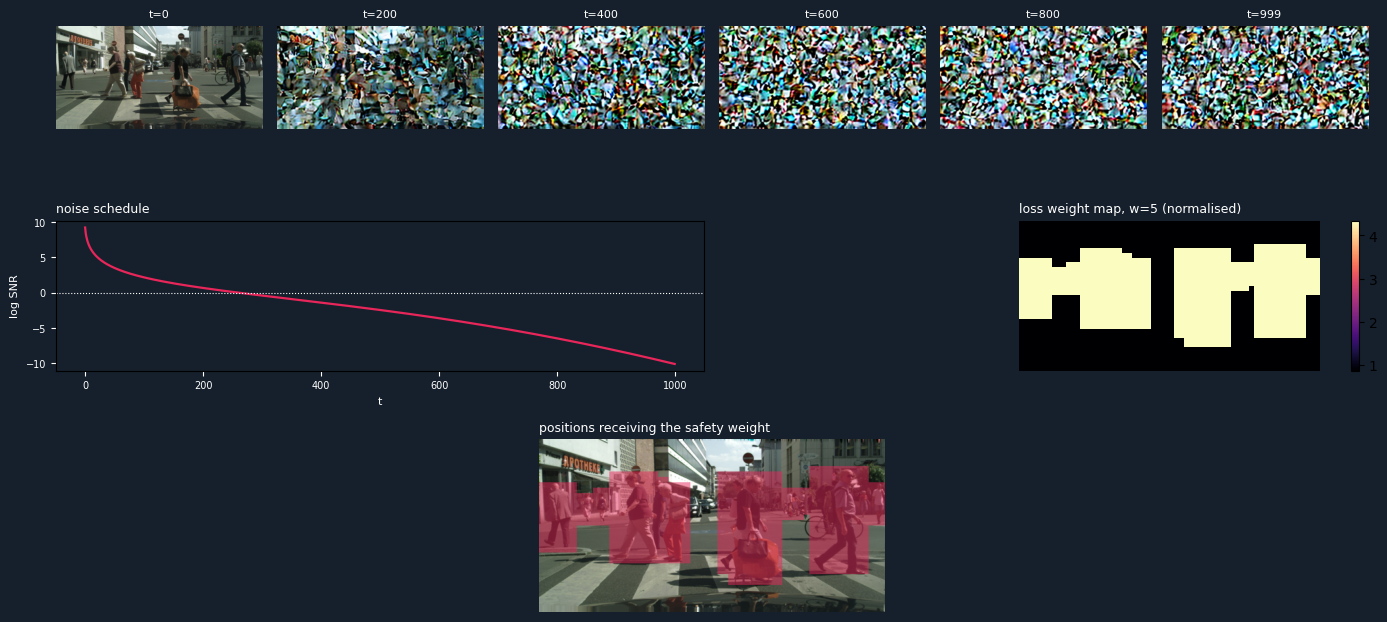

Cell 10 done → Cell 11 = training loop, EMA, checkpointing, latent crop-aug


In [16]:
# ============================================================
# CELL 10 — DDPM schedule · importance-weighted loss
# ============================================================
import os, gc, time
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt

# ---- 1. schedule (float64 cumprod → float32 buffers) ---------------------
_b   = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.num_timesteps, device=dev, dtype=torch.float64)
_ab  = torch.cumprod(1.-_b, 0)
SQAB, SQ1AB = _ab.sqrt().float(), (1.-_ab).sqrt().float()
LOGSNR = (_ab/(1.-_ab)).log().float()

def q_sample(z0, t, noise):
    return SQAB[t][:,None,None,None]*z0 + SQ1AB[t][:,None,None,None]*noise

# ---- 2. importance at LATENT resolution (loss lives here, not cell grid) -
IMP_CACHE = f"{ROOT}/data/imp_latent_{cfg.img_h}x{cfg.img_w}.npy"
if os.path.exists(IMP_CACHE):
    G["imp_lat"] = torch.from_numpy(np.load(IMP_CACHE)).to(dev)
    print("✓ latent importance cache loaded")
else:
    t0 = time.time(); out = np.empty((N, LH, LW), np.float16)
    for k in range(N):
        a, b = C["offsets"][k], C["offsets"][k+1]
        objs = [dict(box=tuple(bx), w=float(w),
                     tier="VRU" if w >= cfg.imp_vru-1e-3 else "VEH")
                for bx, w in zip(C["boxes"][a:b], C["imps"][a:b])]
        I = render_importance(objs, blur=False)                      # (256,512)
        out[k] = I.reshape(LH, cfg.vae_downsample, LW, cfg.vae_downsample).max((1,3))
    np.save(IMP_CACHE, out); G["imp_lat"] = torch.from_numpy(out).to(dev)
    print(f"✓ latent importance built in {time.time()-t0:.0f}s → {out.nbytes/1e6:.0f} MB")

def latent_imp(idx, flip):
    I = G["imp_lat"][idx].float()
    return torch.where(flip[:,None,None], torch.flip(I, [-1]), I)

def raw_weights(I, w, mode="vru"):
    m = (I >= cfg.imp_vru-1e-3).float() if mode == "vru" else \
        ((I-cfg.imp_static)/(cfg.imp_vru-cfg.imp_static)).clamp(0,1)
    return 1. + (w-1.)*m

_Z = {}
def norm_const(w, mode="vru"):
    """Dataset-wide E[W]=1 ⇒ loss scale and gradient scale invariant to w."""
    if (w,mode) not in _Z:
        _Z[(w,mode)] = raw_weights(G["imp_lat"].float(), w, mode).mean().item()
    return _Z[(w,mode)]

# ---- 3. the loss ---------------------------------------------------------
def diffusion_loss(net, b, w=1.0, a_coarse=1.0, a_fine=1.0, drop_p=0.1,
                   mode="vru", gen=None, parts=False):
    z0 = sample_latent(b["idx"], b["flip"])
    Bsz = z0.shape[0]
    t   = torch.randint(0, cfg.num_timesteps, (Bsz,), device=dev, generator=gen)
    eps = torch.randn(z0.shape, device=dev, generator=gen)
    zt  = q_sample(z0, t, eps)
    drop = torch.rand(Bsz, device=dev, generator=gen) < drop_p
    with torch.autocast("cuda", DTYPE):
        pred = net(zt, t, b["grain"], b["box"], b["cls"], b["bimp"], b["bmask"], drop=drop)
    se = (pred.float()-eps).pow(2).mean(1)                    # (B,H,W)

    I = latent_imp(b["idx"], b["flip"])
    W = raw_weights(I, w, mode) / norm_const(w, mode)
    if a_coarse != a_fine:                                    # D²iT per-grain α
        gl = b["grain"].float().repeat_interleave(P,1).repeat_interleave(P,2)
        A  = a_fine*gl + a_coarse*(1-gl); W = W * A / A.mean()
    loss = (se*W).mean()
    if not parts: return loss
    vru = I >= cfg.imp_vru-1e-3
    veh = (I >= cfg.imp_vehicle-1e-3) & ~vru
    m = lambda k: se[k].mean().item() if k.any() else float("nan")
    return loss, dict(vru=m(vru), veh=m(veh), bg=m(~(vru|veh)), all=se.mean().item())

# ============================ VERIFY =====================================
for n_ in ("opt",): globals().pop(n_, None)
gc.collect(); torch.cuda.empty_cache()
torch.manual_seed(cfg.seed); model = PAD2iT().to(dev)          # fresh, zero-init
bar = "─"*68; print(bar)

print(f"  {'t':>6}{'ᾱ':>12}{'√ᾱ':>9}{'√(1-ᾱ)':>10}{'logSNR':>10}")
for t_ in (0, 250, 500, 750, 999):
    print(f"  {t_:>6}{_ab[t_].item():>12.2e}{SQAB[t_]:>9.4f}{SQ1AB[t_]:>10.4f}{LOGSNR[t_]:>10.2f}")
print(f"  {'✓' if (_ab.diff()<0).all() else '✗'} ᾱ strictly decreasing · "
      f"terminal signal std {SQAB[-1].item()*0.808:.4f} ≈ 0 → no residual-signal leak")
print(bar)

b = next(iter(train_batches)); z0 = sample_latent(b["idx"], b["flip"])
for t_ in (0, 500, 999):
    tt = torch.full((z0.shape[0],), t_, device=dev)
    s = q_sample(z0, tt, torch.randn_like(z0)).std().item()
    print(f"  t={t_:<4d} std(z_t) = {s:.3f}" + ("   (≈ latent std)" if t_==0 else
          "   (≈ 1.0, pure noise)" if t_==999 else ""))
print(bar)

I = latent_imp(b["idx"], b["flip"])
frac = (I >= cfg.imp_vru-1e-3).float().mean().item()
print(f"  VRU occupies {frac:.2%} of latent positions   ·   "
      f"vehicle {(((I>=cfg.imp_vehicle-1e-3)&(I<cfg.imp_vru-1e-3)).float().mean()):.2%}")
print(f"  {'w':>4}{'norm Z':>10}{'W(VRU)':>10}{'W(bg)':>9}{'loss':>10}{'‖grad‖':>11}")
for w_ in (1.0, 2.0, 5.0):
    Z = norm_const(w_)
    g = torch.Generator(device=dev).manual_seed(7)             # identical t, ε, drop
    model.zero_grad(set_to_none=True)
    L = diffusion_loss(model, b, w=w_, gen=g)
    L.backward()
    gn = torch.sqrt(sum(p.grad.pow(2).sum() for p in model.parameters() if p.grad is not None))
    print(f"  {w_:>4.0f}{Z:>10.4f}{w_/Z:>10.3f}{1/Z:>9.3f}{L.item():>10.4f}{gn.item():>11.4f}")
model.zero_grad(set_to_none=True)
print(f"  ✓ zero-init loss ≈ E[ε²] = 1.0 at every w  →  normalisation holds,")
print(f"    so w changes WHERE gradient goes, not how much. Same effective LR across ablations.")
print(bar)

L, pr = diffusion_loss(model, b, w=1.0, parts=True)
print(f"  region MSE at init   VRU {pr['vru']:.4f} · vehicle {pr['veh']:.4f} · "
      f"bg {pr['bg']:.4f} · all {pr['all']:.4f}")
print(f"  → track the VRU/bg ratio during training: it previews object-region FID at Gate 2")
print(bar)

# ---- figure ---------------------------------------------------------------
k_ = int((G["imp_lat"][IDX["val"]] >= cfg.imp_vru-1e-3).float().mean((1,2)).argmax())
kid = IDX["val"][k_:k_+1]
fl  = torch.zeros(1, dtype=torch.bool, device=dev)
z_  = sample_latent(kid, fl)
fig = plt.figure(figsize=(14,6.4), facecolor="#16202c")
gsp = fig.add_gridspec(3,6, height_ratios=[1,1,1.15])
with torch.no_grad():
    for c_, t_ in enumerate([0,200,400,600,800,999]):
        zt = q_sample(z_, torch.full((1,), t_, device=dev), torch.randn_like(z_))
        im = ((decode(zt).clamp(-1,1)[0].permute(1,2,0).cpu().float().numpy())+1)/2
        ax = fig.add_subplot(gsp[0,c_]); ax.imshow(im); ax.axis("off")
        ax.set_title(f"t={t_}", color="w", fontsize=8)
ax = fig.add_subplot(gsp[1,:3]); ax.plot(LOGSNR.cpu(), color="#e8265a", lw=1.6)
ax.axhline(0, color="w", ls=":", lw=.8); ax.set_xlabel("t", color="w", fontsize=8)
ax.set_ylabel("log SNR", color="w", fontsize=8)
ax.set_title("noise schedule", color="w", loc="left", fontsize=9)
ax2 = fig.add_subplot(gsp[1,3:])
Wm = (raw_weights(latent_imp(kid, fl), 5.0)/norm_const(5.0))[0].cpu().numpy()
h_ = ax2.imshow(Wm, cmap="magma"); plt.colorbar(h_, ax=ax2, fraction=.025)
ax2.axis("off"); ax2.set_title("loss weight map, w=5 (normalised)", color="w", loc="left", fontsize=9)
ax3 = fig.add_subplot(gsp[2,:])
img_ = (G["img"][kid][0].permute(1,2,0).float()/255).cpu().numpy().copy()
up = np.kron(Wm > 1.01, np.ones((cfg.vae_downsample,)*2)).astype(bool)
img_[up] = .5*img_[up] + .5*np.array([.91,.15,.35])
ax3.imshow(img_); ax3.axis("off")
ax3.set_title("positions receiving the safety weight", color="w", loc="left", fontsize=9)
for a_ in (ax, ax2):
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
plt.tight_layout(); plt.savefig(f"{ROOT}/samples/cell10_schedule_loss.png", dpi=110,
    facecolor="#16202c", bbox_inches="tight"); plt.show()
print("Cell 10 done → Cell 11 = training loop, EMA, checkpointing, latent crop-aug")

✓ val set frozen: 128 images × 4 noise levels, fixed ε ⇒ val loss comparable across steps and arms
──────────────────────────────────────────────────────────────────────
  SMOKE TEST — pa_d2it, 300 steps
──────────────────────────────────────────────────────────────────────
        50  loss 0.9966  ‖g‖  0.98   3.2 it/s  eta   1.3m
       100  loss 0.9525  ‖g‖  2.57   3.2 it/s  eta   1.0m
            VAL loss 0.8928 | VRU 0.8351 veh 0.8387 bg 0.9019 | VRU/bg 0.926
       150  loss 0.7226  ‖g‖  2.26   3.1 it/s  eta   0.8m
       200  loss 0.4148  ‖g‖  0.87   3.2 it/s  eta   0.5m
            VAL loss 0.2142 | VRU 0.2265 veh 0.2306 bg 0.2118 | VRU/bg 1.070
       250  loss 0.2733  ‖g‖  1.24   3.1 it/s  eta   0.3m
       300  loss 0.2106  ‖g‖  0.78   3.2 it/s  eta   0.0m
            VAL loss 0.1797 | VRU 0.2147 veh 0.2167 bg 0.1738 | VRU/bg 1.235
  ✓ pa_d2it: 300 steps in 1.7 min
──────────────────────────────────────────────────────────────────────
  val loss   0.8928 → 0.1797   (✓ learnin

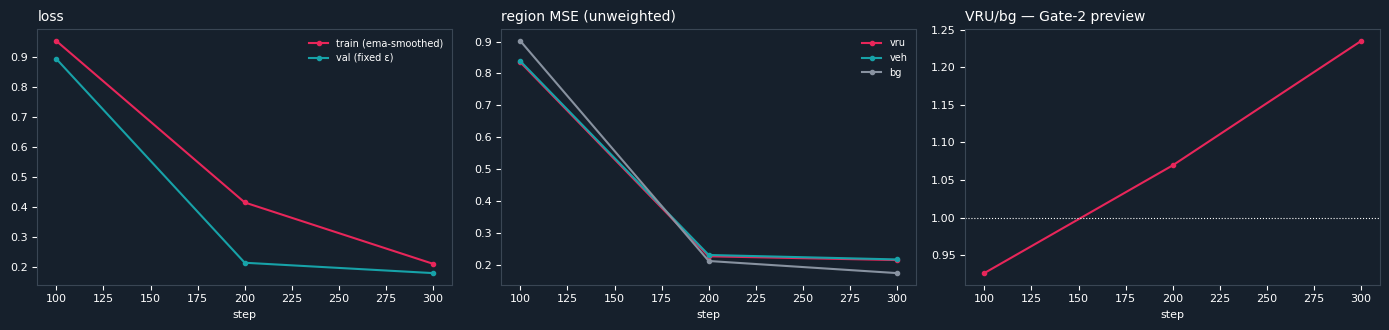

Cell 11 done → Cell 12 = launch all 5 arms


In [17]:
# ============================================================
# CELL 11 — Training loop · EMA · checkpoints · fixed-noise val
# ============================================================
import os, gc, json, time, glob
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt

CKPT = f"{ROOT}/checkpoints"; os.makedirs(CKPT, exist_ok=True)

ARMS = {   # w=1.0 everywhere ⇒ H1 isolates the SIGNAL, nothing else
 "dit_b":        dict(signal="importance", k=0,      layout=False, w=1.0),
 "dit_b_layout": dict(signal="importance", k=0,      layout=True,  w=1.0),
 "d2it_b":       dict(signal="entropy",    k=K_FINE, layout=True,  w=1.0),
 "pa_d2it":      dict(signal="importance", k=K_FINE, layout=True,  w=1.0),
 "random_ctrl":  dict(signal="random",     k=K_FINE, layout=True,  w=1.0),
}

class EMA:
    def __init__(self, model, decay=cfg.ema_decay):
        self.decay = decay
        self.sh = {k: v.detach().clone().float() for k, v in model.state_dict().items()}
    @torch.no_grad()
    def update(self, model, step):
        d = min(self.decay, (1.+step)/(10.+step))       # warm start
        for k, v in model.state_dict().items(): self.sh[k].lerp_(v.detach().float(), 1.-d)

def save_ckpt(name, model, ema, opt, step, hist):
    p = f"{CKPT}/{name}_s{step:06d}.pt"
    torch.save(dict(model=model.state_dict(), ema=ema.sh, opt=opt.state_dict(),
                    step=step, arm=ARMS[name], hist=hist), p)
    for o in sorted(glob.glob(f"{CKPT}/{name}_s*.pt"))[:-cfg.keep_last_ckpts]: os.remove(o)
    json.dump(hist, open(f"{ROOT}/logs/{name}_hist.json","w"))
    return p

latest_ckpt = lambda n: (sorted(glob.glob(f"{CKPT}/{n}_s*.pt")) or [None])[-1]

# ---- fixed-noise validation (diffusion val loss is useless otherwise) ----
@torch.no_grad()
def build_val_fixed(n_img=128, ts=(125,375,625,875), seed=1234):
    g   = torch.Generator(device=dev).manual_seed(seed)
    ids = IDX["val"][:n_img]; fl = torch.zeros(n_img, dtype=torch.bool, device=dev)
    z0  = sample_latent(ids, fl)                              # frozen posterior draw
    I   = latent_imp(ids, fl)
    vru = I >= cfg.imp_vru-1e-3; veh = (I >= cfg.imp_vehicle-1e-3) & ~vru
    return dict(ids=ids, fl=fl, z0=z0, ts=ts,
                eps=torch.randn((len(ts),)+z0.shape, device=dev, generator=g),
                vru=vru, veh=veh, bg=~(vru|veh))

@torch.no_grad()
def evaluate(net, vf, vb, w=1.0):
    b = vb.get(vf["ids"]); acc = {k:0. for k in ("loss","vru","veh","bg","all")}
    W = raw_weights(latent_imp(vf["ids"], vf["fl"]), w) / norm_const(w)
    for li, t_ in enumerate(vf["ts"]):
        t  = torch.full((len(vf["ids"]),), t_, device=dev)
        zt = q_sample(vf["z0"], t, vf["eps"][li])
        with torch.autocast("cuda", DTYPE):
            pred = net(zt, t, b["grain"], b["box"], b["cls"], b["bimp"], b["bmask"])
        se = (pred.float()-vf["eps"][li]).pow(2).mean(1)
        acc["loss"] += (se*W).mean().item(); acc["all"] += se.mean().item()
        for k in ("vru","veh","bg"): acc[k] += se[vf[k]].mean().item()
    return {k: v/len(vf["ts"]) for k, v in acc.items()}

VF = build_val_fixed()
print(f"✓ val set frozen: {len(VF['ids'])} images × {len(VF['ts'])} noise levels, "
      f"fixed ε ⇒ val loss comparable across steps and arms")

# ---- the loop -------------------------------------------------------------
def train_arm(name, steps, resume=True, log_every=50, val_every=500,
              ckpt_every=2000, bs=None, lr=None, compile_=False, quiet=False):
    arm, bs, lr = ARMS[name], bs or cfg.batch_size, lr or cfg.lr
    gc.collect(); torch.cuda.empty_cache()
    torch.manual_seed(cfg.seed)                        # identical init across arms
    model = PAD2iT(arm["k"], arm["layout"]).to(dev)
    emod  = PAD2iT(arm["k"], arm["layout"]).to(dev).eval().requires_grad_(False)
    ema   = EMA(model)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, betas=cfg.adam_betas,
                              weight_decay=cfg.weight_decay)
    hist, step = [], 0
    ck = latest_ckpt(name) if resume else None
    if ck:
        s = torch.load(ck, map_location=dev, weights_only=False)
        model.load_state_dict(s["model"]); ema.sh = {k: v.to(dev) for k,v in s["ema"].items()}
        opt.load_state_dict(s["opt"]); step, hist = s["step"], s["hist"]
        print(f"  ↻ resumed {name} @ step {step}")
    net = torch.compile(model) if compile_ else model
    tb  = GPUBatcher("train", signal=arm["signal"], bs=bs)
    vb  = GPUBatcher("val",   signal=arm["signal"], shuffle=False, augment=False)

    def stream():
        while True:
            for b in tb: yield b
    it, run, t0, tstep = stream(), None, time.time(), time.time()

    while step < steps:
        b = next(it)
        for g_ in opt.param_groups: g_["lr"] = lr*min(1., (step+1)/cfg.warmup_steps)
        loss = diffusion_loss(net, b, w=arm["w"])
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip).item()
        opt.step(); opt.zero_grad(set_to_none=True); ema.update(model, step); step += 1
        l = loss.item(); run = l if run is None else .98*run + .02*l

        if step % log_every == 0 and not quiet:
            sps = log_every/(time.time()-tstep); tstep = time.time()
            print(f"    {step:>6}  loss {run:.4f}  ‖g‖ {gn:5.2f}  "
                  f"{sps:4.1f} it/s  eta {(steps-step)/sps/60:5.1f}m", flush=True)
        if step % val_every == 0 or step == steps:
            emod.load_state_dict({k: v for k, v in ema.sh.items()})
            v = evaluate(emod, VF, vb, arm["w"])
            hist.append(dict(step=step, train=run, **v, ratio=v["vru"]/v["bg"]))
            if not quiet:
                print(f"    {'':>6}  VAL loss {v['loss']:.4f} | VRU {v['vru']:.4f} "
                      f"veh {v['veh']:.4f} bg {v['bg']:.4f} | VRU/bg {v['vru']/v['bg']:.3f}")
        if step % ckpt_every == 0 or step == steps:
            save_ckpt(name, model, ema, opt, step, hist)
    print(f"  ✓ {name}: {step} steps in {(time.time()-t0)/60:.1f} min")
    del model, opt, net; gc.collect(); torch.cuda.empty_cache()
    return hist

# ============================ SMOKE TEST =================================
bar = "─"*70; print(bar); print("  SMOKE TEST — pa_d2it, 300 steps"); print(bar)
h = train_arm("pa_d2it", 300, resume=False, log_every=50, val_every=100, ckpt_every=300)

print(bar)
d = h[0], h[-1]
print(f"  val loss   {d[0]['loss']:.4f} → {d[-1]['loss']:.4f}   "
      f"({'✓ learning' if d[-1]['loss'] < d[0]['loss'] else '✗ not learning'})")
print(f"  VRU/bg     {d[0]['ratio']:.3f} → {d[-1]['ratio']:.3f}")
sz = os.path.getsize(latest_ckpt('pa_d2it'))/1e9
print(f"  ckpt {sz:.2f} GB × {cfg.keep_last_ckpts} kept × 5 arms = {sz*cfg.keep_last_ckpts*5:.1f} GB on Drive")
print(bar)

fig, ax = plt.subplots(1, 3, figsize=(14,3.4), facecolor="#16202c")
s_ = [x["step"] for x in h]
ax[0].plot(s_, [x["train"] for x in h], "-o", ms=3, color="#e8265a", label="train (ema-smoothed)")
ax[0].plot(s_, [x["loss"]  for x in h], "-o", ms=3, color="#17a2a8", label="val (fixed ε)")
ax[0].set_title("loss", color="w", loc="left", fontsize=10)
for k_, c_ in [("vru","#e8265a"), ("veh","#17a2a8"), ("bg","#8892a0")]:
    ax[1].plot(s_, [x[k_] for x in h], "-o", ms=3, color=c_, label=k_)
ax[1].set_title("region MSE (unweighted)", color="w", loc="left", fontsize=10)
ax[2].plot(s_, [x["ratio"] for x in h], "-o", ms=3, color="#e8265a")
ax[2].axhline(1., color="w", ls=":", lw=.8)
ax[2].set_title("VRU/bg — Gate-2 preview", color="w", loc="left", fontsize=10)
for a_ in ax:
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=8)
    a_.set_xlabel("step", color="w", fontsize=8)
    for s2 in a_.spines.values(): s2.set_color("#3a4654")
    if a_ is not ax[2]: a_.legend(fontsize=7, facecolor="#16202c", labelcolor="w", edgecolor="none")
plt.tight_layout(); plt.savefig(f"{ROOT}/samples/cell11_smoke.png", dpi=110,
    facecolor="#16202c", bbox_inches="tight"); plt.show()
print("Cell 11 done → Cell 12 = launch all 5 arms")